In [1]:
# pip install kagglehub[pandas-datasets]

# TS Academy Capstone Project — Group 04  
# IBM HR Analytics Employee Attrition & Workforce Intelligence Project

## Final Submission Notebook

This notebook combines all project stages into one end-to-end workflow:

1. Data Foundation  
2. Feature Engineering and Encoding  
3. Clustering Analysis  
4. Classification Modelling  
5. Imbalance Handling  
6. Clustering and Classification Tie-In  
7. Final Conclusion and Recommendations  

The notebook is designed to tell the complete business analytics story from raw data through to HR recommendations.


### Depth Track Chosen: Clustering


### All team members
**Ndubuaku George Ekwueme**

**Oludare Benjamin**

**Adebowale Ayodele**

**Sewanu Gideon**

**Emmanuel Fajembola**

**Adeoye Joshua**

**Nkiruka Sarah**

**Joy Migwi**

In [2]:
# Path setup for local Jupyter / GitHub repo execution
# This notebook was designed to run from inside the repository.
# If it is opened from the project root, this cell moves the working directory into /notebooks
# so that existing relative paths such as ../data/... continue to work.

from pathlib import Path
import os

current_dir = Path.cwd()

if (current_dir / "data").exists() and (current_dir / "notebooks").exists():
    os.chdir(current_dir / "notebooks")
elif (current_dir.parent / "data").exists():
    # Already likely inside /notebooks
    pass

print("Current working directory:", Path.cwd())
print("Project root:", Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())


Current working directory: C:\Users\caspe\Downloads
Project root: C:\Users\caspe\Downloads


---

# Table of Contents

- [Part 1 — Data Foundation](#Part-1-—-Data-Foundation)
- [Part 2 — Feature Engineering and Encoding](#Part-2-—-Feature-Engineering-and-Encoding)
- [Part 3 — Clustering Analysis](#Part-3-—-Clustering-Analysis)
- [Part 4 — Classification Modelling](#Part-4-—-Classification-Modelling)
- [Part 5 — Imbalance Handling](#Part-5-—-Imbalance-Handling)
- [Parts 6 and 7 — Tie-In, Conclusion, and Recommendations](#Parts-6-and-7-—-Tie-In,-Conclusion,-and-Recommendations)


---

# Part 1 — Data Foundation

_Source notebook: `01_data_foundation.ipynb`_

# TS Academy Capstone Project — Group 04  
## IBM HR Analytics Employee Attrition  
### Part 1: Data Foundation

This notebook section focuses on building the foundation for the full employee attrition analysis.  
The aim is to understand the structure and quality of the dataset before moving into feature engineering, clustering, classification, and imbalance handling.

The business problem is that the company wants to understand patterns behind employee attrition and eventually predict which employees are most likely to leave.

For this first stage, I will:
- Load and inspect the dataset
- Push the data into SQLite
- Run SQL queries to generate early business insights
- Perform exploratory data analysis
- Check missing values and duplicates
- Prepare a clean dataset for the next stage

In [3]:
from pathlib import Path

# Define project directories
RAW_DATA_DIR = Path("../data/raw")
PROCESSED_DATA_DIR = Path("../data/processed")
REPORTS_DIR = Path("../reports")
MODELS_DIR = Path("../models")

# Create directories if missing
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project directories ready.")

Project directories ready.


In [4]:
# Core data handling
import pandas as pd
import numpy as np

# SQLite database
import sqlite3

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Basic plot style
sns.set(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
import os
print(os.getcwd())

C:\Users\caspe\Downloads


In [6]:
#import os

#file_path = "../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"

#print(os.path.exists(file_path))

In [7]:
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

# ============================================================
# Load IBM HR Analytics Employee Attrition Dataset
# ============================================================

# File path inside the Kaggle dataset
file_path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

C:\Users\caspe\anaconda\envs\genexa_ds\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Loading the Dataset

The dataset used for this project is the IBM HR Analytics Employee Attrition dataset.  
Each row represents one employee, and the target variable is `Attrition`, which indicates whether the employee left the company or stayed.

At this stage, I am loading the raw dataset without making changes so that I can first understand its original structure.

In [8]:
# Load dataset directly from Kaggle
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "pavansubhasht/ibm-hr-analytics-attrition-dataset",
    file_path
)

# ============================================================
# Preview Dataset
# ============================================================

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

C:\Users\caspe\AppData\Local\Temp\ipykernel_19728\1801097174.py:2: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Dataset Shape: (1470, 35)

First 5 Rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2



Column Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [9]:
# Load the dataset
#df = pd.read_csv(file_path)

# Preview the first 5 rows
#df.head()

## 2. Dataset Overview

Before cleaning or modelling, I need to understand the size, structure, and data types in the dataset.  
This helps identify which columns are numerical, categorical, constant, or potentially useful for future analysis.

In [10]:
# Check the number of rows and columns
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Display column names
df.columns.tolist()

Number of rows: 1470
Number of columns: 35


['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [11]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [12]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [13]:
# Summary of categorical columns
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Column: BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Column: Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Column: EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Column: Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

Column: JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int

### Initial Dataset Observations

observations:
- The dataset contains 1470 rows and 35 columns.
- The target variable is `Attrition`.
- Most features are numerical, but there are several categorical features such as `Department`, `BusinessTravel`, `Gender`, `JobRole`, `MaritalStatus`, and `OverTime`.
- Some columns may not provide useful predictive signal if they contain only one unique value.

## 3. Data Quality Checks

In this section, I check for common data quality issues such as missing values, duplicate rows, and columns with only one unique value.  
This is important because poor data quality can weaken clustering and classification later in the project.

In [14]:
# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values_df = pd.DataFrame({
    "column": missing_values.index,
    "missing_count": missing_values.values,
    "missing_percentage": (missing_values.values / len(df)) * 100
})

missing_values_df

,column,missing_count,missing_percentage
0,Age,0,0.0
1,Attrition,0,0.0
2,BusinessTravel,0,0.0
3,DailyRate,0,0.0
4,Department,0,0.0
5,DistanceFromHome,0,0.0
6,Education,0,0.0
7,EducationField,0,0.0
8,EmployeeCount,0,0.0
9,EmployeeNumber,0,0.0


In [15]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [16]:
# Check number of unique values in each column
unique_counts = df.nunique().sort_values()

unique_counts

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [17]:
# Columns with only one unique value
constant_columns = unique_counts[unique_counts == 1].index.tolist()

print("Constant columns:", constant_columns)

Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']


### Data Quality Findings

findings:
- There are no missing values in the dataset.
- There are no duplicate rows.
- Some columns such as `EmployeeCount`, `Over18`, and `StandardHours` contain only one unique value. These columns are unlikely to help future modelling because they do not vary between employees.
- I will not drop them immediately in this foundation stage unless clearly justified, but I will flag them for removal before modelling.

## 4. Loading the Dataset into SQLite

The project requires the data to be pushed into a SQLite database.  
This allows me to query the dataset using SQL and produce early business insights before moving into Python-based analysis.

In [18]:
# Create SQLite connection
conn = sqlite3.connect(":memory:")

# Save dataframe as SQL table
df.to_sql("hr_attrition", conn, index=False, if_exists="replace")

print("Dataset successfully loaded into SQLite table: hr_attrition")

Dataset successfully loaded into SQLite table: hr_attrition


In [19]:
# Preview SQL table
query = """
SELECT *
FROM hr_attrition
LIMIT 5;
"""

pd.read_sql(query, conn)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 5. SQL Query 1: Attrition by Department

This query checks whether attrition differs across departments.  
This is useful because some departments may experience higher employee turnover than others, which could point to workload, management, culture, or role-specific issues.

In [20]:
query = """
SELECT 
    Department,
    COUNT(*) AS total_employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS employees_left,
    ROUND(
        100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 
        2
    ) AS attrition_rate_percent
FROM hr_attrition
GROUP BY Department
ORDER BY attrition_rate_percent DESC;
"""

attrition_by_department = pd.read_sql(query, conn)
attrition_by_department

,Department,total_employees,employees_left,attrition_rate_percent
0,Sales,446,92,20.63
1,Human Resources,63,12,19.05
2,Research & Development,961,133,13.84


### SQL Query 1 Insight

The Sales department recorded the highest attrition rate at 20.63%, followed by Human Resources at 19.05%, while Research & Development had the lowest attrition rate at 13.84%.

Although Research & Development had the largest number of employees overall, its attrition rate was significantly lower than Sales. This suggests that employee attrition is not evenly distributed across departments and may be influenced by department-specific factors such as workload, job pressure, career progression opportunities, compensation structure, or management practices.

The high attrition rate within the Sales department may indicate increased performance pressure, demanding targets, or lower employee retention levels compared with other departments. Human Resources also shows a relatively high attrition rate despite having a smaller workforce, which may suggest internal organisational or job satisfaction challenges.

These findings indicate that `Department` is likely to be an important feature for later stages of the project, including feature engineering, clustering, and classification modelling.

## 6. SQL Query 2: Attrition by Overtime

This query checks the relationship between overtime and employee attrition.  
Overtime is important because employees working longer hours may be more likely to experience burnout or dissatisfaction.

In [21]:
query = """
SELECT 
    OverTime,
    COUNT(*) AS total_employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS employees_left,
    ROUND(
        100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 
        2
    ) AS attrition_rate_percent
FROM hr_attrition
GROUP BY OverTime
ORDER BY attrition_rate_percent DESC;
"""

attrition_by_overtime = pd.read_sql(query, conn)
attrition_by_overtime

,OverTime,total_employees,employees_left,attrition_rate_percent
0,Yes,416,127,30.53
1,No,1054,110,10.44


### SQL Query 2 Insight

Findings:
- Employees who work overtime have an attrition rate of **30.53%**.
- Employees who do not work overtime have an attrition rate of **10.44%**.
- This may suggest that overtime is an important risk factor for attrition.

## 7. SQL Query 3: Average Monthly Income by Attrition Status

This query compares average monthly income between employees who stayed and employees who left.  
Income can be a useful indicator because lower pay may contribute to dissatisfaction or external job seeking.

In [22]:
query = """
SELECT 
    Attrition,
    COUNT(*) AS total_employees,
    ROUND(AVG(MonthlyIncome), 2) AS avg_monthly_income,
    ROUND(MIN(MonthlyIncome), 2) AS min_monthly_income,
    ROUND(MAX(MonthlyIncome), 2) AS max_monthly_income
FROM hr_attrition
GROUP BY Attrition;
"""

income_by_attrition = pd.read_sql(query, conn)
income_by_attrition

,Attrition,total_employees,avg_monthly_income,min_monthly_income,max_monthly_income
0,No,1233,6832.74,1051.0,19999.0
1,Yes,237,4787.09,1009.0,19859.0


### SQL Query 3 Insight

Findings:
- Employees who left had an average monthly income of **4787.09**.
- Employees who stayed had an average monthly income of **6832.74**.
- If employees who left earned less on average, this may indicate that compensation is linked to attrition risk.

## 8. SQL Query: Attrition by Job Role

This query checks which job roles have the highest attrition rates.  
This is useful because attrition may be concentrated in specific roles rather than spread evenly across the company.

In [23]:
query = """
SELECT 
    JobRole,
    COUNT(*) AS total_employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS employees_left,
    ROUND(
        100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 
        2
    ) AS attrition_rate_percent
FROM hr_attrition
GROUP BY JobRole
ORDER BY attrition_rate_percent DESC;
"""

attrition_by_jobrole = pd.read_sql(query, conn)
attrition_by_jobrole

,JobRole,total_employees,employees_left,attrition_rate_percent
0,Sales Representative,83,33,39.76
1,Laboratory Technician,259,62,23.94
2,Human Resources,52,12,23.08
3,Sales Executive,326,57,17.48
4,Research Scientist,292,47,16.10
5,Manufacturing Director,145,10,6.90
6,Healthcare Representative,131,9,6.87
7,Manager,102,5,4.90
8,Research Director,80,2,2.50


### SQL Query Insight

Findings:
- The job role with the highest attrition rate is **Sales Representative**.
- This may suggest role-specific retention challenges.

## 9. Exploratory Data Analysis

After using SQL to generate early business insights, I now use Python visualisations to understand the target variable and selected features.

The focus is on:
- `Attrition`
- `Age`
- `MonthlyIncome`
- `OverTime`
- `JobSatisfaction`
- `YearsAtCompany`

These variables are relevant because they relate to employee demographics, compensation, workload, satisfaction, and tenure.

In [24]:
# Attrition count
attrition_counts = df["Attrition"].value_counts()
attrition_percentages = df["Attrition"].value_counts(normalize=True) * 100

print("Attrition Counts:")
print(attrition_counts)

print("\nAttrition Percentages:")
print(attrition_percentages.round(2))

Attrition Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Percentages:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


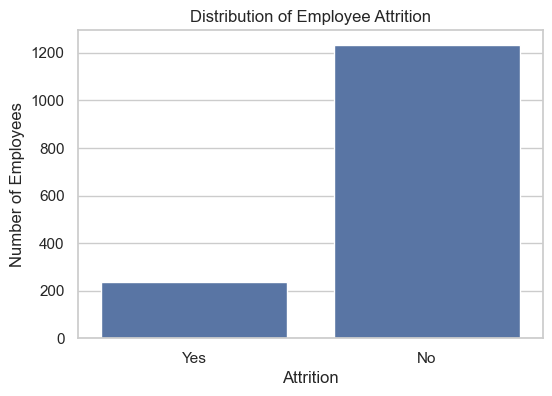

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Attrition")
plt.title("Distribution of Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

### Target Variable Insight

Findings:
- The dataset is imbalanced because more employees stayed than left.
- This is important because later classification models may become biased toward predicting the majority class.
- This confirms why imbalance handling will be needed later in the project.

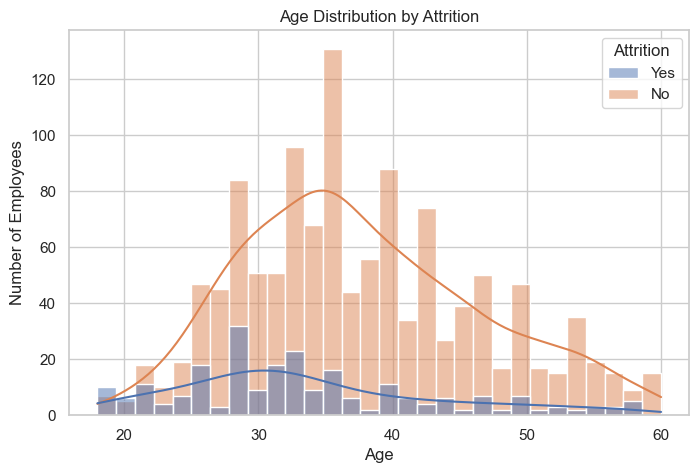

In [26]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="Attrition", kde=True, bins=30)
plt.title("Age Distribution by Attrition")
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.show()

### Age Insight

The age distribution shows that employee attrition is more concentrated among younger and mid-career employees, particularly between the ages of approximately 25 and 35. Employees who left the company appear to cluster more heavily within this age range compared with older employees.

As employee age increases, the number of attrition cases generally decreases. Employees above the age of 45 appear less likely to leave the company, which may suggest stronger organisational attachment, greater job stability, higher seniority, or better compensation and benefits.

This pattern suggests that younger employees may be more likely to explore external career opportunities, seek faster salary growth, or change jobs more frequently. It may also indicate that early-career employees are more sensitive to workload, career progression, workplace satisfaction, or work-life balance issues.

The findings suggest that `Age` could become an important predictive feature during later classification modelling and may also help form meaningful employee segments during clustering analysis.

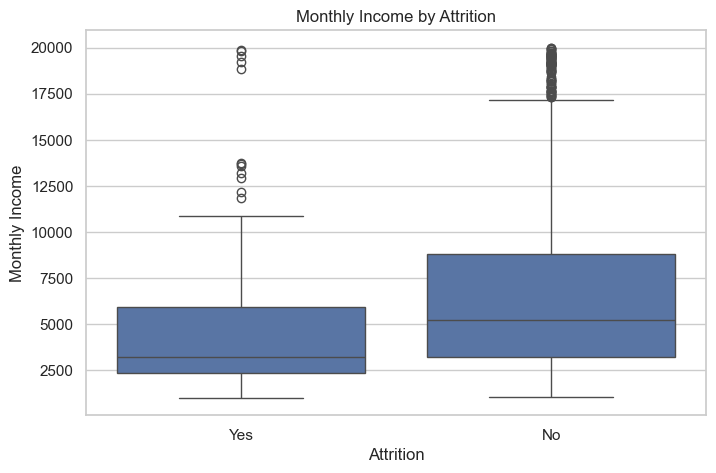

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome")
plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

### Monthly Income Insight

Findings:
- Employees who left have lower median monthly income compared with employees who stayed.
- This suggests compensation may be linked to attrition risk.

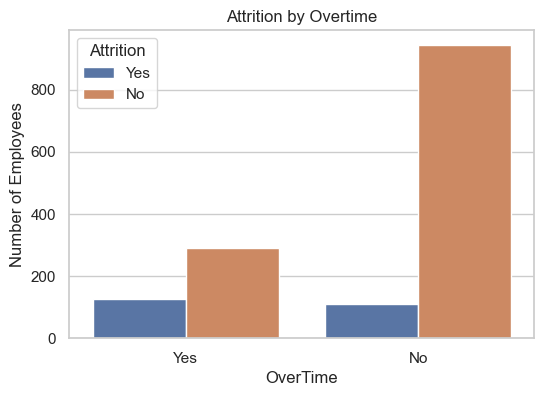

In [28]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="OverTime", hue="Attrition")
plt.title("Attrition by Overtime")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")
plt.show()

### Overtime Insight

The visualisation shows a strong relationship between overtime and employee attrition. Employees who work overtime appear significantly more likely to leave the company compared with employees who do not work overtime.

Although the company has more employees who do not work overtime overall, the proportion of attrition cases is noticeably higher among employees working overtime. This suggests that excessive workload, burnout, stress, or poor work-life balance may contribute to employees leaving the organisation.

The findings indicate that `OverTime` may become one of the strongest predictive features during later classification modelling. It may also play an important role in identifying high-risk employee groups during clustering analysis.

From a business perspective, the company may need to investigate workload distribution, staffing levels, and employee wellbeing initiatives to reduce attrition among employees frequently working overtime.

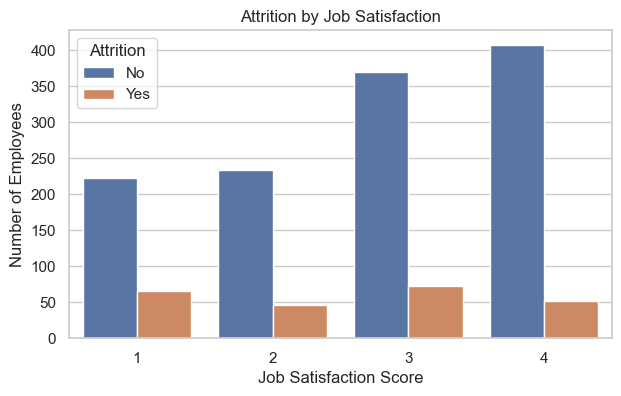

In [29]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="JobSatisfaction", hue="Attrition")
plt.title("Attrition by Job Satisfaction")
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Number of Employees")
plt.show()

### Job Satisfaction Insight

The analysis suggests a relationship between job satisfaction and employee attrition. Employees with lower job satisfaction scores appear more likely to leave the company compared with employees reporting higher satisfaction levels.

Attrition cases are particularly noticeable among employees with satisfaction scores of 1 and 2, while employees with higher satisfaction scores generally show lower attrition levels. Although attrition still exists among employees with high satisfaction, the overall proportion appears lower relative to the larger employee population in those categories.

This pattern suggests that employee satisfaction may influence retention and organisational commitment. Employees who are less satisfied may be more likely to seek external opportunities, experience disengagement, or feel disconnected from their work environment.

The findings indicate that `JobSatisfaction` is likely to be an important feature for future predictive modelling and employee segmentation. From a business perspective, improving workplace culture, recognition, career growth opportunities, and employee engagement initiatives may help reduce attrition risk.

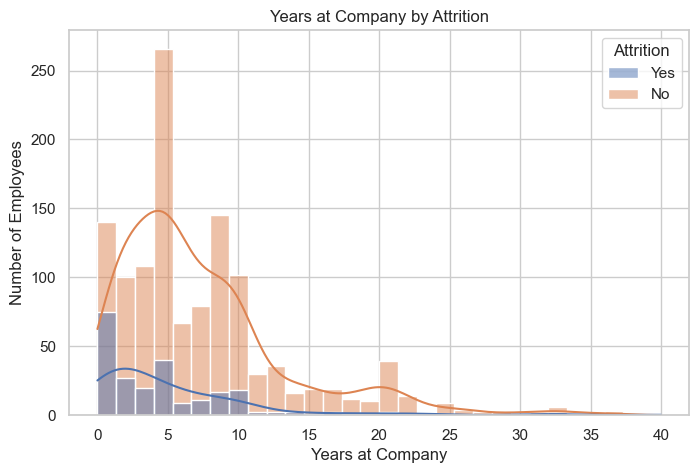

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="YearsAtCompany", hue="Attrition", kde=True, bins=30)
plt.title("Years at Company by Attrition")
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")
plt.show()

### Years at Company Insight

The distribution of years at company suggests that attrition is more common among employees with shorter tenure, particularly during the early years of employment. Employees who left the company appear concentrated within the first few years, while longer-tenured employees show lower attrition levels overall.

This pattern may indicate that the organisation experiences higher turnover among newer employees, possibly due to onboarding challenges, unmet expectations, career mobility, or adjustment difficulties within the company.

As tenure increases, attrition cases become less frequent, which may suggest that employees who remain longer develop stronger organisational attachment, better career stability, and greater commitment to the company.

The findings suggest that `YearsAtCompany` could become an important predictive feature in later classification models and may also help define employee personas during clustering analysis. From a business perspective, the company may benefit from improving early-career employee engagement, onboarding processes, mentorship programmes, and retention strategies during the first few years of employment.

## 10. Initial Cleaning Decisions

The purpose of this stage is not to transform the dataset heavily.  
Instead, I will make basic cleaning decisions that prepare the data for feature engineering in the next stage.

Cleaning checks include:
- Removing duplicate rows if present
- Flagging constant columns
- Confirming missing values
- Preserving the original meaning of the dataset

In [31]:
# Create a copy of the raw dataset before cleaning
df_clean = df.copy()

# Remove duplicate rows if any exist
df_clean = df_clean.drop_duplicates()

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")

Original shape: (1470, 35)
Cleaned shape: (1470, 35)


In [32]:
# Identify constant columns again
constant_columns = [col for col in df_clean.columns if df_clean[col].nunique() == 1]

constant_columns

['EmployeeCount', 'Over18', 'StandardHours']

### Cleaning Decision

- No missing values were found, so no imputation was required.
- No Duplicate rows were found.
- Constant columns such as `EmployeeCount`, `Over18`, and `StandardHours` were flagged because they do not add analytical value.
- I will keep the dataset mostly unchanged at this stage to avoid making premature modelling decisions before feature engineering.

**Note:** The duplicate save of `hr_attrition_clean_day1.csv` into the `notebooks/` folder was removed. The clean dataset is saved correctly to `../data/processed/`.

In [33]:
df_clean.to_csv(PROCESSED_DATA_DIR / "hr_attrition_clean_day1.csv", index=False)

print("Saved successfully")

Saved successfully


## 11. Day 1 Summary

Today’s work established the foundation for the employee attrition project.

The dataset was loaded, inspected, and pushed into SQLite for SQL-based analysis.  
Initial SQL queries explored attrition by department, overtime, income, and job role.  
Exploratory data analysis was then used to examine the target variable and important features such as age, monthly income, overtime, job satisfaction, and years at company.

The key finding from this foundation stage is that attrition is not random.  
Early patterns suggest that factors such as overtime, income, department, job role, satisfaction, and tenure may help explain why employees leave.

The dataset appears ready for the next stage: feature engineering and encoding.

---

# Part 2 — Feature Engineering and Encoding

_Source notebook: `02_feature_engineering.ipynb`_

# TS Academy Capstone Project — Group 04
## Part 2: Feature Engineering and Encoding

In this stage of the project, I transform the cleaned employee attrition dataset into a modelling-ready dataset by creating new business-driven features, encoding categorical variables, and scaling numerical variables.

The aim is to improve the dataset’s ability to reveal hidden employee patterns during clustering and improve predictive performance during classification.

This stage focuses on:
- Feature engineering
- Business interpretation
- Encoding strategies
- Feature scaling
- Preparing the dataset for clustering and machine learning

In [34]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Loading the Cleaned Dataset

I will now load the cleaned dataset created during Part 1.

This dataset already passed:
- missing value checks,
- duplicate checks,
- basic quality assessment.

The goal now is to engineer more meaningful HR-related features that may better explain attrition patterns.

In [35]:
df = pd.read_csv("../data/processed/hr_attrition_clean_day1.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [36]:
print(df.shape)

df.info()

(1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel     

## 2. Feature Engineering

Feature engineering is the process of creating new variables from existing data to improve business understanding and machine learning performance.

Instead of relying only on raw columns, engineered features help capture:
- employee behaviour,
- tenure patterns,
- compensation trends,
- workload risk,
- and satisfaction-related insights.

### Feature 1: Age Group

This feature groups employees into career-stage categories based on age.

Business reasoning:
- Younger employees may be more likely to switch jobs frequently.
- Mid-career employees may prioritize career growth and compensation.
- Older employees may have greater organisational stability.

This feature may help uncover hidden attrition patterns across employee age groups.

In [37]:
# Create age groups
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18, 25, 35, 45, 60],
    labels=['Young', 'EarlyCareer', 'MidCareer', 'Senior']
)

df[['Age', 'AgeGroup']].head()

,Age,AgeGroup
0,41,MidCareer
1,49,Senior
2,37,MidCareer
3,33,EarlyCareer
4,27,EarlyCareer


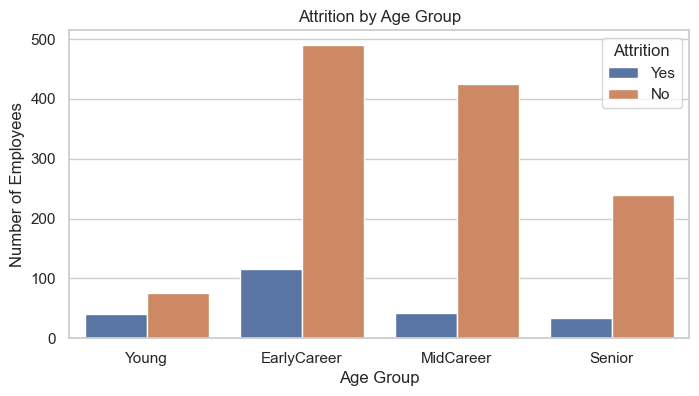

In [38]:
plt.figure(figsize=(8, 4))

sns.countplot(data=df, x='AgeGroup', hue='Attrition')

plt.title("Attrition by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")

plt.show()

### Age Group Insight

The analysis shows that employees in the EarlyCareer age group experience the highest attrition levels compared with other age categories. MidCareer employees also show noticeable attrition, while Senior employees appear relatively more stable within the organisation.

This suggests that younger employees may be more likely to leave due to career mobility, salary expectations, career exploration, or limited organisational attachment during the earlier stages of employment.

The findings indicate that employee age and career stage may strongly influence retention patterns. As a result, `AgeGroup` may become an important feature during future clustering and classification analysis.

### Feature 2: Income Band

This feature groups employees into salary bands.

Business reasoning:
- Employees with lower compensation may have higher attrition risk.
- Higher earners may have stronger organisational attachment and benefits.

Grouping income into bands also improves interpretability for business stakeholders.

In [39]:
# Create income bands
df['IncomeBand'] = pd.qcut(
    df['MonthlyIncome'],
    q=4,
    labels=['Low', 'Medium', 'High', 'VeryHigh']
)

df[['MonthlyIncome', 'IncomeBand']].head()

,MonthlyIncome,IncomeBand
0,5993,High
1,5130,High
2,2090,Low
3,2909,Low
4,3468,Medium


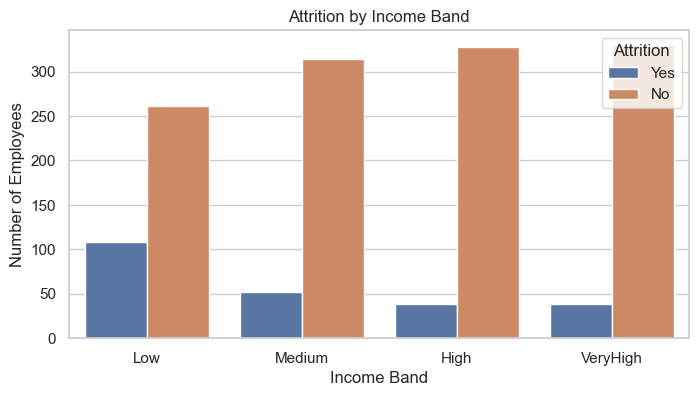

In [40]:
plt.figure(figsize=(8, 4))

sns.countplot(data=df, x='IncomeBand', hue='Attrition')

plt.title("Attrition by Income Band")
plt.xlabel("Income Band")
plt.ylabel("Number of Employees")

plt.show()

### Income Band Insight

The visualisation suggests that employees within the Low income band experience the highest attrition levels compared with employees in higher income categories.

As income levels increase, attrition appears to decrease. Employees in the High and VeryHigh income bands show relatively lower attrition rates, which may indicate stronger organisational attachment, improved job satisfaction, or better financial incentives to remain with the company.

These findings suggest that compensation may play an important role in employee retention and that salary-related variables may become important predictors during future modelling stages.

### Feature 3: Years at Company Group

This feature categorises employees based on tenure within the organisation.

Business reasoning:
- Employees in their first few years may still be evaluating the company.
- Long-tenure employees may have stronger loyalty and organisational attachment.

This feature may help identify vulnerable employee retention periods.

In [41]:
df['YearsAtCompanyGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=[-1, 2, 5, 10, 40],
    labels=['New', 'EarlyTenure', 'Established', 'LongTenure']
)

df[['YearsAtCompany', 'YearsAtCompanyGroup']].head()

,YearsAtCompany,YearsAtCompanyGroup
0,6,Established
1,10,Established
2,0,New
3,8,Established
4,2,New


### Years at Company Group Insight

The analysis suggests that employees with shorter organisational tenure show higher attrition levels compared with long-tenure employees.

Employees within the New and EarlyTenure groups appear more likely to leave the company, which may indicate onboarding challenges, unmet expectations, career uncertainty, or limited organisational attachment during the early stages of employment.

In contrast, employees within the Established and LongTenure groups appear more stable, suggesting that retention improves as employees spend more time within the organisation.

These findings suggest that tenure-related features may play an important role in future clustering and predictive modelling tasks.

### Feature 4: Overtime Risk Indicator

This feature converts overtime into a binary risk indicator.

Business reasoning:
- Employees working overtime may face burnout or work-life imbalance.
- This feature simplifies workload-related risk analysis.

In [42]:
df['OvertimeRisk'] = df['OverTime'].map({
    'Yes': 1,
    'No': 0
})

df[['OverTime', 'OvertimeRisk']].head()

,OverTime,OvertimeRisk
0,Yes,1
1,No,0
2,Yes,1
3,Yes,1
4,No,0


### Overtime Risk Insight

The overtime risk indicator simplifies workload-related analysis by converting overtime participation into a binary risk feature.

Employees working overtime may experience higher levels of stress, burnout, or work-life imbalance, all of which can contribute to attrition risk.

This feature may become highly valuable during future classification modelling because earlier exploratory analysis already suggested a strong relationship between overtime and employee attrition.

### Feature 5: Work-Life Satisfaction Score

This feature combines:
- WorkLifeBalance
- JobSatisfaction

Business reasoning:
- Employee dissatisfaction is often multi-dimensional.
- Combining work-life balance and job satisfaction may better represent overall employee wellbeing.

In [43]:
df['WorkLifeSatisfactionScore'] = (
    df['WorkLifeBalance'] + df['JobSatisfaction']
)

df[['WorkLifeBalance', 'JobSatisfaction', 'WorkLifeSatisfactionScore']].head()

,WorkLifeBalance,JobSatisfaction,WorkLifeSatisfactionScore
0,1,4,5
1,3,2,5
2,3,3,6
3,3,3,6
4,3,2,5


### Work-Life Satisfaction Score Insight

The WorkLifeSatisfactionScore feature combines work-life balance and job satisfaction into a single wellbeing-related metric.

This engineered feature may better capture overall employee experience because dissatisfaction is often influenced by multiple interconnected factors rather than a single variable alone.

Employees with lower combined wellbeing scores may be more likely to experience disengagement, reduced motivation, or increased attrition risk.

This feature may improve future clustering analysis by helping identify employee wellbeing segments and may also improve predictive performance during classification.

### Feature 6: Income Growth Potential

This feature measures employee compensation relative to total career experience.

Business reasoning:
- Employees with many years of experience but relatively low compensation may feel undervalued.
- Employees whose compensation does not appear to match their experience level may become more likely to seek external opportunities.

This feature acts as a proxy for perceived compensation growth and career reward progression.

In [44]:
# Create income growth potential feature
df['IncomeGrowthPotential'] = (
    df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)
)

df[['MonthlyIncome', 'TotalWorkingYears', 'IncomeGrowthPotential']].head()

,MonthlyIncome,TotalWorkingYears,IncomeGrowthPotential
0,5993,8,665.888889
1,5130,10,466.363636
2,2090,7,261.250000
3,2909,8,323.222222
4,3468,6,495.428571


### Income Growth Potential Insight

The IncomeGrowthPotential feature estimates employee compensation relative to overall career experience.

Employees with lower compensation relative to their total working years may feel undervalued or perceive slower financial progression within the organisation. This may increase the likelihood of external job searching and eventual attrition.

This feature may help future machine learning models capture hidden compensation dissatisfaction patterns that are not fully visible when using MonthlyIncome alone.

In [45]:
# Drop constant/no-signal columns
constant_cols = ['EmployeeCount', 'Over18', 'StandardHours']

df.drop(columns=constant_cols, inplace=True)

print("Constant columns removed.")

Constant columns removed.


## 3. Encoding Categorical Variables

Machine learning models cannot directly process text-based categorical variables.

Therefore, categorical variables must be encoded into numerical representations.

Encoding decisions:
- Binary variables → Label Encoding
- Nominal variables → One-Hot Encoding
- Ordered variables → Label Encoding

In [46]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

categorical_cols

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

### Encoding Strategy Justification

I used:
- Label encoding for binary categorical variables because they only contain two categories.
- One-hot encoding for nominal variables because there is no natural order between categories.
- `drop_first=True` was used during one-hot encoding to reduce multicollinearity and avoid redundant dummy variables.

In [47]:
# Binary columns
binary_cols = ['Attrition', 'Gender', 'OverTime']

# Apply label encoding
le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df[binary_cols].head()

,Attrition,Gender,OverTime
0,1,0,1
1,0,1,0
2,1,1,1
3,0,0,1
4,0,1,0


In [48]:
# Nominal categorical columns
nominal_cols = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'JobRole',
    'MaritalStatus',
    'AgeGroup',
    'IncomeBand',
    'YearsAtCompanyGroup'
]

# Apply one-hot encoding
df = pd.get_dummies(
    df,
    columns=nominal_cols,
    drop_first=True
)

# Convert boolean columns to integers
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,AgeGroup_EarlyCareer,AgeGroup_MidCareer,AgeGroup_Senior,IncomeBand_Medium,IncomeBand_High,IncomeBand_VeryHigh,YearsAtCompanyGroup_EarlyTenure,YearsAtCompanyGroup_Established,YearsAtCompanyGroup_LongTenure
0,41,1,1102,1,2,1,2,0,94,3,2,4,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5,1,5,665.888889,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0
1,49,0,279,8,1,2,3,1,61,2,2,2,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7,0,5,466.363636,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,1,0
2,37,1,1373,2,2,4,4,1,92,2,1,3,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0,1,6,261.250000,0,1,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0
3,33,0,1392,3,4,5,4,0,56,3,1,3,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0,1,6,323.222222,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0
4,27,0,591,2,1,7,1,1,40,3,1,2,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2,0,5,495.428571,0,1,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0


## 4. Feature Scaling

Feature scaling is important because:
- clustering algorithms are distance-based,
- variables exist on different scales,
- larger-value features may dominate smaller-value features.

I selected `StandardScaler` because:
- it standardises features around mean = 0 and standard deviation = 1,
- it performs well for clustering algorithms such as K-Means,
- and it is suitable for HR data containing mixed numerical ranges.

In [49]:
# Copy dataframe before scaling
df_scaled = df.copy()

# Columns to exclude
exclude_cols = ['Attrition']

# Select numeric columns
numeric_cols = df_scaled.drop(columns=exclude_cols).select_dtypes(include=np.number).columns

# Initialize scaler
scaler = StandardScaler()

# Scale numeric features
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

df_scaled.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,AgeGroup_EarlyCareer,AgeGroup_MidCareer,AgeGroup_Senior,IncomeBand_Medium,IncomeBand_High,IncomeBand_VeryHigh,YearsAtCompanyGroup_EarlyTenure,YearsAtCompanyGroup_Established,YearsAtCompanyGroup_LongTenure
0,0.446350,1,0.742527,-1.010909,-0.891688,-1.701283,-0.660531,-1.224745,1.383138,0.379672,-0.057788,1.153254,-0.108350,0.726020,2.125136,1.591746,-1.150554,-0.426230,-1.584178,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834,1.591746,-0.377447,0.275215,-0.481859,0.639841,-1.374051,1.515244,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308
1,1.322365,0,-1.297775,-0.147150,-1.868426,-1.699621,0.254625,0.816497,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,1.488876,-0.678049,-0.628241,2.129306,2.346151,1.191438,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541,-0.628241,-0.377447,-0.425971,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.837490,-0.683422,2.093947,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308
2,0.008343,1,1.414363,-0.887515,-0.891688,-1.696298,1.169781,0.816497,1.284725,-1.026167,-0.961486,0.246200,-0.937654,-1.674841,1.324226,1.591746,-0.057267,-0.426230,-0.658973,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935,1.591746,0.393174,-1.146796,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,-0.679141,4.114223,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308
3,-0.429664,0,1.461466,-0.764121,1.061787,-1.694636,1.169781,-1.224745,-0.486709,0.379672,-0.961486,0.246200,-0.763634,1.243211,-0.678049,1.591746,-1.150554,-0.426230,0.266233,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935,1.591746,0.393174,-0.929009,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.194045,-0.683422,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,1.510381,-0.448308
4,-1.086676,0,-0.524295,-0.887515,-1.868426,-1.691313,-1.575686,0.816497,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,0.325900,2.525591,-0.628241,-0.877232,-0.426230,1.191438,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227,-0.628241,-0.377447,-0.323829,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,1.472448,-0.243059,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,1.194045,-0.683422,-0.477567,1.736777,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308


### Scaling Observation

The numerical features were successfully standardised using `StandardScaler`, resulting in variables centered around a mean of approximately 0 with a standard deviation of 1.

Before scaling, features such as `MonthlyIncome`, `DistanceFromHome`, `TotalWorkingYears`, and `DailyRate` existed on very different numerical ranges. Without scaling, larger-value variables could dominate distance calculations and negatively affect clustering quality.

After scaling, all numerical variables now exist on comparable scales, which is especially important for distance-based algorithms such as K-Means clustering. This ensures that no single feature disproportionately influences employee segmentation purely because of its magnitude.

The scaled dataset is now better prepared for:
- clustering analysis,
- PCA dimensionality reduction,
- classification modelling,
- and future imbalance handling techniques.

Scaling also improves model stability and helps machine learning algorithms learn patterns more effectively from the HR dataset.

In [50]:
print("Final dataset shape:", df_scaled.shape)

Final dataset shape: (1470, 58)


In [51]:
df_scaled.to_csv(PROCESSED_DATA_DIR / "hr_attrition_feature_engineered.csv", index=False)

print("Feature-engineered dataset saved successfully.")

Feature-engineered dataset saved successfully.


## 5. Part 2 Summary

In this stage, I transformed the cleaned HR dataset into a modelling-ready dataset through feature engineering, encoding, and scaling.

Several business-driven features were created to better capture employee behaviour, tenure, workload, compensation, and satisfaction patterns. These engineered variables may improve the ability of future clustering and classification models to identify hidden employee segments and predict attrition risk.

Categorical variables were encoded appropriately using label encoding and one-hot encoding depending on their structure, while StandardScaler was applied to ensure numerical variables exist on comparable scales for distance-based clustering analysis.

The final dataset is now prepared for the next stage of the project: clustering analysis.

---

# Part 3 — Clustering Analysis

_Source notebook: `03_clustering.ipynb`_

# Part 3: Clustering Analysis

In this section, I use K-Means clustering to segment employees into meaningful groups based on their demographic, compensation, satisfaction, workload, and tenure-related characteristics.

The aim is to identify hidden employee groups that may not be obvious from basic exploratory analysis.

Because clustering is an unsupervised learning method, the target variable `Attrition` will not be used to create the clusters. Instead, attrition will only be analysed after the clusters have been created to understand whether some groups have higher leaving risk.

In [52]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load the Feature-Engineered Dataset

I will now load the feature-engineered and scaled dataset created in Part 2.

This dataset has already been cleaned, encoded, and scaled, making it suitable for K-Means clustering.

In [53]:
df = pd.read_csv("../data/processed/hr_attrition_feature_engineered.csv")

df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,AgeGroup_EarlyCareer,AgeGroup_MidCareer,AgeGroup_Senior,IncomeBand_Medium,IncomeBand_High,IncomeBand_VeryHigh,YearsAtCompanyGroup_EarlyTenure,YearsAtCompanyGroup_Established,YearsAtCompanyGroup_LongTenure
0,0.446350,1,0.742527,-1.010909,-0.891688,-1.701283,-0.660531,-1.224745,1.383138,0.379672,-0.057788,1.153254,-0.108350,0.726020,2.125136,1.591746,-1.150554,-0.426230,-1.584178,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834,1.591746,-0.377447,0.275215,-0.481859,0.639841,-1.374051,1.515244,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308
1,1.322365,0,-1.297775,-0.147150,-1.868426,-1.699621,0.254625,0.816497,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,1.488876,-0.678049,-0.628241,2.129306,2.346151,1.191438,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541,-0.628241,-0.377447,-0.425971,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.837490,-0.683422,2.093947,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308
2,0.008343,1,1.414363,-0.887515,-0.891688,-1.696298,1.169781,0.816497,1.284725,-1.026167,-0.961486,0.246200,-0.937654,-1.674841,1.324226,1.591746,-0.057267,-0.426230,-0.658973,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935,1.591746,0.393174,-1.146796,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,-0.679141,4.114223,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308
3,-0.429664,0,1.461466,-0.764121,1.061787,-1.694636,1.169781,-1.224745,-0.486709,0.379672,-0.961486,0.246200,-0.763634,1.243211,-0.678049,1.591746,-1.150554,-0.426230,0.266233,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935,1.591746,0.393174,-0.929009,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.194045,-0.683422,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,1.510381,-0.448308
4,-1.086676,0,-0.524295,-0.887515,-1.868426,-1.691313,-1.575686,0.816497,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,0.325900,2.525591,-0.628241,-0.877232,-0.426230,1.191438,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227,-0.628241,-0.377447,-0.323829,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,1.472448,-0.243059,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,1.194045,-0.683422,-0.477567,1.736777,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308


In [54]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (1470, 58)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 58 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1470 non-null   float64
 1   Attrition                          1470 non-null   int64  
 2   DailyRate                          1470 non-null   float64
 3   DistanceFromHome                   1470 non-null   float64
 4   Education                          1470 non-null   float64
 5   EmployeeNumber                     1470 non-null   float64
 6   EnvironmentSatisfaction            1470 non-null   float64
 7   Gender                             1470 non-null   float64
 8   HourlyRate                         1470 non-null   float64
 9   JobInvolvement                     1470 non-null   float64
 10  JobLevel                           1470 non-null   float64
 11  JobSatisfaction               

## 2. Prepare Data for Clustering

The target variable `Attrition` must be excluded from clustering because K-Means is unsupervised. Including the target would leak information into the clustering process and make the segmentation less realistic.

If present, employee identifier columns such as `EmployeeNumber` should also be removed because they do not describe employee behaviour or HR characteristics.

In [55]:
# Create a copy of the dataset
df_cluster = df.copy()

# Keep Attrition separately for later interpretation
attrition = df_cluster["Attrition"]

# Columns to exclude from clustering
exclude_cols = ["Attrition"]

# Remove EmployeeNumber if it exists because it is only an identifier
if "EmployeeNumber" in df_cluster.columns:
    exclude_cols.append("EmployeeNumber")

# Create clustering feature matrix
X_cluster = df_cluster.drop(columns=exclude_cols)

print("Clustering feature shape:", X_cluster.shape)
X_cluster.head()

Clustering feature shape: (1470, 56)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,AgeGroup_EarlyCareer,AgeGroup_MidCareer,AgeGroup_Senior,IncomeBand_Medium,IncomeBand_High,IncomeBand_VeryHigh,YearsAtCompanyGroup_EarlyTenure,YearsAtCompanyGroup_Established,YearsAtCompanyGroup_LongTenure
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,-1.224745,1.383138,0.379672,-0.057788,1.153254,-0.108350,0.726020,2.125136,1.591746,-1.150554,-0.426230,-1.584178,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834,1.591746,-0.377447,0.275215,-0.481859,0.639841,-1.374051,1.515244,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,0.816497,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,1.488876,-0.678049,-0.628241,2.129306,2.346151,1.191438,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541,-0.628241,-0.377447,-0.425971,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.837490,-0.683422,2.093947,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,0.816497,1.284725,-1.026167,-0.961486,0.246200,-0.937654,-1.674841,1.324226,1.591746,-0.057267,-0.426230,-0.658973,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935,1.591746,0.393174,-1.146796,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,-0.679141,4.114223,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-1.224745,-0.486709,0.379672,-0.961486,0.246200,-0.763634,1.243211,-0.678049,1.591746,-1.150554,-0.426230,0.266233,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935,1.591746,0.393174,-0.929009,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.194045,-0.683422,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,1.510381,-0.448308
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,0.816497,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,0.325900,2.525591,-0.628241,-0.877232,-0.426230,1.191438,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227,-0.628241,-0.377447,-0.323829,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,1.472448,-0.243059,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,1.194045,-0.683422,-0.477567,1.736777,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308


## 3. Choosing the Number of Clusters

To decide the best number of clusters, I will test K values from 2 to 10 using:

- Elbow method: shows how compact the clusters are.
- Silhouette score: shows how well-separated the clusters are.

The final K should not be selected based only on the chart. It should also make business sense and produce interpretable employee groups.

In [56]:
# Store results
k_values = range(2, 11)
inertia_scores = []
silhouette_scores = []

# Run K-Means for each K
for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_cluster)
    
    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, cluster_labels))

# Create results table
k_results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_scores,
    "SilhouetteScore": silhouette_scores
})

k_results

,K,Inertia,SilhouetteScore
0,2,75057.505115,0.124096
1,3,70667.807758,0.083900
2,4,68434.026388,0.064730
3,5,66337.068106,0.076999
4,6,64605.944524,0.079537
5,7,63281.001488,0.076942
6,8,62292.006092,0.069793
7,9,60709.745666,0.078411
8,10,59314.518893,0.081095


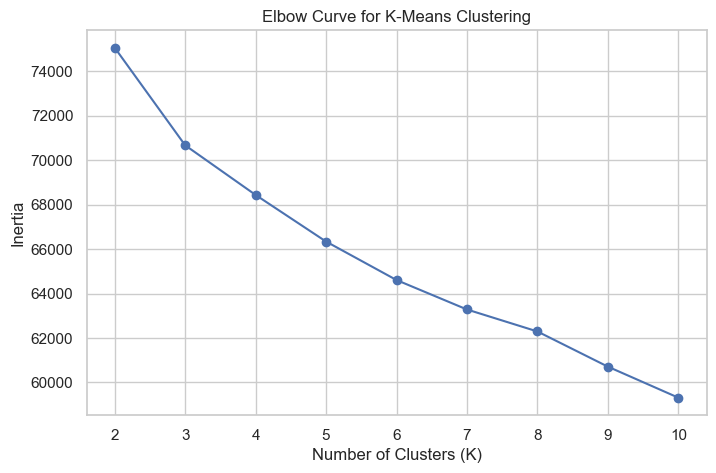

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(k_results["K"], k_results["Inertia"], marker="o")

plt.title("Elbow Curve for K-Means Clustering")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

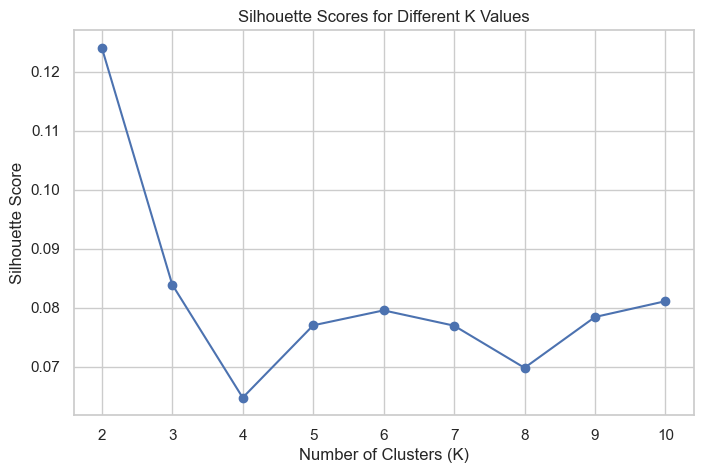

In [58]:
plt.figure(figsize=(8, 5))

plt.plot(k_results["K"], k_results["SilhouetteScore"], marker="o")

plt.title("Silhouette Scores for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

### Choosing the Best K

The elbow curve shows a strong reduction in inertia between K = 2 and K = 5, after which the rate of improvement begins to slow down. This suggests that adding more clusters beyond this point produces diminishing returns in terms of cluster compactness.

The silhouette score is highest at K = 2 with a score of approximately 0.124. However, while K = 2 provides the strongest mathematical separation, it produces only two very broad employee groups, which may oversimplify the workforce and limit the usefulness of the segmentation for HR decision-making.

After K = 2, the silhouette scores become lower but relatively stable between K = 5 and K = 10. Among these values, K = 5 provides a good balance between cluster separation, business interpretability, and practical usefulness.

From a business perspective, K = 5 allows the company to identify multiple employee personas such as:
- high-risk early-career employees,
- overworked employees,
- stable long-tenure employees,
- compensation-sensitive employees,
- and highly satisfied core employees.

This level of segmentation is detailed enough to support targeted HR interventions while still remaining understandable for non-technical stakeholders.

Although higher K values such as K = 7 or K = 10 provide more granular segmentation, they may create clusters that are too small or too complex for practical business action.

Based on both the clustering metrics and business interpretability, I selected K = 5 as the final number of clusters for the employee segmentation analysis.

## Depth Track Chosen: Clustering

For the depth track, I selected clustering analysis. Instead of only running one K-Means model, I compared multiple clustering structures using K = 3, K = 5, and K = 7.

This allowed me to evaluate how employee personas changed as the number of clusters increased. I compared each clustering structure based on interpretability, attrition risk, business usefulness, and HR actionability.

The final recommended clustering solution was K = 5 because it provided the strongest balance between analytical detail and practical business interpretation.

In [59]:
# Choose final K after reviewing elbow and silhouette results
final_k = 5

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

df_cluster["Cluster"] = final_kmeans.fit_predict(X_cluster)

df_cluster["Cluster"].value_counts().sort_index()

Cluster
0     83
1    262
2    305
3    497
4    323
Name: count, dtype: int64

## 4. Cluster Profiling

After creating the clusters, I will profile each group by calculating average values for key variables.

This helps translate numerical clusters into business-friendly employee segments.

I will also calculate attrition rate per cluster to understand whether some groups appear more at risk of leaving.

In [60]:
cluster_size = df_cluster["Cluster"].value_counts().sort_index()

cluster_size_df = pd.DataFrame({
    "Cluster": cluster_size.index,
    "Number of Employees": cluster_size.values,
    "Percentage of Workforce": (cluster_size.values / len(df_cluster) * 100).round(2)
})

cluster_size_df

,Cluster,Number of Employees,Percentage of Workforce
0,0,83,5.65
1,1,262,17.82
2,2,305,20.75
3,3,497,33.81
4,4,323,21.97


In [61]:
cluster_attrition = df_cluster.groupby("Cluster")["Attrition"].agg(
    total_employees="count",
    attrition_count="sum",
    attrition_rate="mean"
).reset_index()

cluster_attrition["attrition_rate"] = (cluster_attrition["attrition_rate"] * 100).round(2)

cluster_attrition

,Cluster,total_employees,attrition_count,attrition_rate
0,0,83,33,39.76
1,1,262,18,6.87
2,2,305,53,17.38
3,3,497,100,20.12
4,4,323,33,10.22


In [62]:
# Select key features for cluster profiling
profile_columns = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "JobSatisfaction",
    "WorkLifeBalance",
    "YearsAtCompany",
    "TotalWorkingYears",
    "OvertimeRisk",
    "WorkLifeSatisfactionScore",
    "IncomeGrowthPotential"
]

# Keep only columns that exist in the dataframe
profile_columns = [col for col in profile_columns if col in df_cluster.columns]

cluster_profile = df_cluster.groupby("Cluster")[profile_columns].mean().round(2)

cluster_profile

,Age,MonthlyIncome,DistanceFromHome,JobSatisfaction,WorkLifeBalance,YearsAtCompany,TotalWorkingYears,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential
Cluster,,,,,,,,,,
0,-0.72,-0.82,-0.07,0.01,0.18,-0.67,-0.85,0.01,0.11,0.42
1,1.02,1.81,-0.03,-0.04,0.01,1.09,1.56,0.02,-0.03,0.25
2,-0.08,0.02,0.05,0.06,0.07,-0.06,-0.14,0.01,0.09,0.22
3,-0.28,-0.62,-0.07,-0.01,-0.04,-0.68,-0.58,0.01,-0.03,0.00
4,-0.14,-0.32,0.11,-0.01,-0.06,0.38,-0.02,-0.05,-0.04,-0.52


### Cluster Profile Findings

#### Cluster 0 — High-Risk Early-Career Employees

- This cluster contains approximately 5.65% of the workforce.
- Employees in this group show lower-than-average income, lower tenure, and lower total working years.
- The cluster also shows slightly higher work-life balance and satisfaction scores compared with some other groups, but still records the highest attrition rate overall.
- Attrition rate: 39.76%.

Business interpretation:
This cluster appears to represent younger or less experienced employees who may still be exploring career opportunities or seeking faster growth elsewhere. Despite not showing extremely poor satisfaction scores, their low tenure and lower compensation may make them more likely to leave.

Potential HR action:
- Improve onboarding and mentorship programmes.
- Increase career development visibility.
- Review early-career compensation and progression pathways.
- Introduce retention-focused engagement during the first few years of employment.

**"Early-Career Flight Risk Employees"**

---

#### Cluster 1 — Stable High-Value Experienced Employees

- This cluster represents approximately 17.82% of the workforce.
- Employees in this group have the highest income levels, longest tenure, and highest total working years among all clusters.
- Attrition rate is the lowest among all clusters at 6.87%.
- Overtime risk and satisfaction levels appear relatively stable.

Business interpretation:
This cluster likely represents experienced, well-established employees with strong organisational attachment and higher compensation. These employees may occupy senior, specialist, or leadership-oriented roles.

Potential HR action:
- Focus on retention through leadership development and recognition.
- Preserve engagement through career advancement opportunities.
- Use this group as mentors for newer employees.

**"Stable Experienced Core Employees"**

---

#### Cluster 2 — Balanced Mid-Level Employees

- This cluster contains approximately 20.75% of the workforce.
- Employees in this group appear close to average across most variables including income, tenure, satisfaction, and overtime exposure.
- Attrition rate is moderate at 17.38%.

Business interpretation:
This cluster may represent mid-level employees who are relatively stable but not strongly attached to the organisation. Because they are close to organisational averages, they may become vulnerable to attrition if external opportunities become more attractive.

Potential HR action:
- Maintain engagement initiatives.
- Monitor career progression and internal mobility opportunities.
- Improve long-term development planning.

**"Moderately Stable Mid-Career Employees"**

---

#### Cluster 3 — Compensation-Sensitive Employees

- This is the largest cluster, representing approximately 33.81% of the workforce.
- Employees in this cluster have lower-than-average income, lower tenure, and lower total working years.
- Work-life balance and job satisfaction also appear slightly below average.
- Attrition rate is relatively high at 20.12%.

Business interpretation:
This group may include employees who feel financially undervalued or insufficiently rewarded relative to their workload or expectations. Their lower satisfaction and compensation levels may contribute to increased turnover risk.

Potential HR action:
- Review compensation fairness and promotion pathways.
- Improve employee recognition programmes.
- Provide clearer career growth opportunities.

**"Compensation-Sensitive Retention Risk Employees"**

---

#### Cluster 4 — Long-Tenure Moderately Stable Employees

- This cluster represents approximately 21.97% of the workforce.
- Employees in this group have above-average tenure but only moderately below-average income.
- Overtime exposure appears slightly lower than average.
- Attrition rate is relatively low at 10.22%.

Business interpretation:
This cluster appears to represent employees who have developed moderate organisational loyalty over time. Although they are not among the highest earners, their longer tenure suggests stronger stability and attachment to the organisation.

Potential HR action:
- Maintain retention through engagement and recognition.
- Continue supporting work-life balance initiatives.
- Offer skill development and internal mobility opportunities to prevent stagnation.

**"Stable Long-Tenure Employees"**

In [63]:
cluster_summary = cluster_profile.merge(
    cluster_attrition,
    on="Cluster",
    how="left"
)

cluster_summary

,Cluster,Age,MonthlyIncome,DistanceFromHome,JobSatisfaction,WorkLifeBalance,YearsAtCompany,TotalWorkingYears,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,total_employees,attrition_count,attrition_rate
0,0,-0.72,-0.82,-0.07,0.01,0.18,-0.67,-0.85,0.01,0.11,0.42,83,33,39.76
1,1,1.02,1.81,-0.03,-0.04,0.01,1.09,1.56,0.02,-0.03,0.25,262,18,6.87
2,2,-0.08,0.02,0.05,0.06,0.07,-0.06,-0.14,0.01,0.09,0.22,305,53,17.38
3,3,-0.28,-0.62,-0.07,-0.01,-0.04,-0.68,-0.58,0.01,-0.03,0.00,497,100,20.12
4,4,-0.14,-0.32,0.11,-0.01,-0.06,0.38,-0.02,-0.05,-0.04,-0.52,323,33,10.22


## 5. Business-Friendly Cluster Names

The purpose of clustering is not just to produce numbers. The clusters should be translated into employee personas that HR and business stakeholders can understand.

Each cluster is given a business-friendly name based on its profile.

In [64]:
cluster_name_map = {
    0: "Early-Career Flight Risk Employees",
    1: "Stable Experienced Core Employees",
    2: "Moderately Stable Mid-Career Employees",
    3: "Compensation-Sensitive Retention Risk Employees",
    4: "Stable Long-Tenure Employees"
}

# Map cluster names
df_cluster["ClusterName"] = df_cluster["Cluster"].map(cluster_name_map)

# Preview results
df_cluster[["Cluster", "ClusterName"]].head(10)

,Cluster,ClusterName
0,2,Moderately Stable Mid-Career Employees
1,4,Stable Long-Tenure Employees
2,3,Compensation-Sensitive Retention Risk Employees
3,4,Stable Long-Tenure Employees
4,3,Compensation-Sensitive Retention Risk Employees
5,4,Stable Long-Tenure Employees
6,3,Compensation-Sensitive Retention Risk Employees
7,3,Compensation-Sensitive Retention Risk Employees
8,4,Stable Long-Tenure Employees
9,4,Stable Long-Tenure Employees


### Cluster Naming Justification

The clusters were renamed using business-friendly labels to make the segmentation easier for HR stakeholders and non-technical audiences to understand.

The names were based on:
- attrition risk,
- employee tenure,
- income levels,
- experience,
- and satisfaction-related characteristics.

Cluster naming allows the clustering analysis to move beyond technical segmentation and become more actionable from a workforce management perspective.

Summary of cluster names:

- Cluster 0 → Early-Career Flight Risk Employees
- Cluster 1 → Stable Experienced Core Employees
- Cluster 2 → Moderately Stable Mid-Career Employees
- Cluster 3 → Compensation-Sensitive Retention Risk Employees
- Cluster 4 → Stable Long-Tenure Employees

## 6. PCA Visualisation

Since the dataset has many features, PCA is used to reduce the data to two dimensions for visualisation.

This does not replace the full clustering analysis. It simply helps visualise how the clusters separate in a two-dimensional space.

In [65]:
pca = PCA(n_components=2, random_state=42)

pca_components = pca.fit_transform(X_cluster)

pca_df = pd.DataFrame({
    "PCA1": pca_components[:, 0],
    "PCA2": pca_components[:, 1],
    "Cluster": df_cluster["Cluster"],
    "Attrition": df_cluster["Attrition"]
})

pca_df.head()

,PCA1,PCA2,Cluster,Attrition
0,-0.053900,2.506083,2,1
1,0.555332,-1.320352,4,0
2,-2.420448,-1.525058,3,1
3,-1.431671,-1.014485,4,0
4,-2.501139,-1.494964,3,0


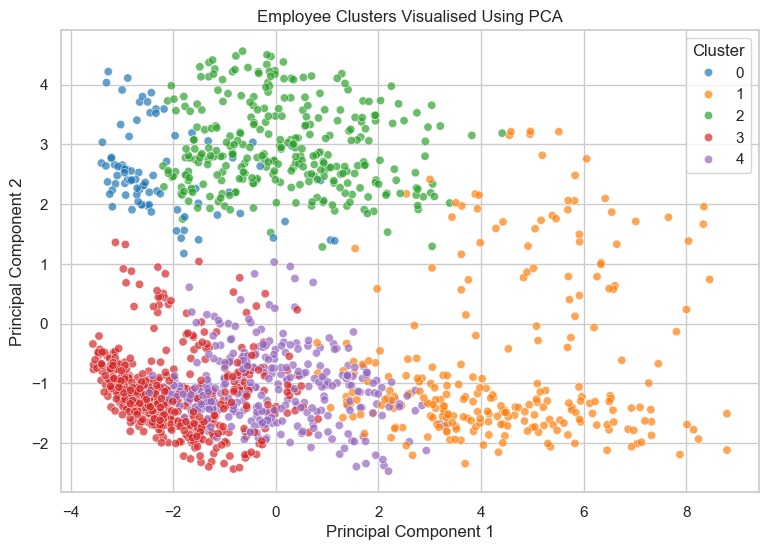

In [66]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="tab10",
    alpha=0.7
)

plt.title("Employee Clusters Visualised Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

### PCA Visualisation Findings

The PCA visualisation shows that the K-Means clustering model successfully identified several distinct employee groupings within the workforce, although some overlap exists between clusters. This overlap is expected because employee behaviour, satisfaction, compensation, and tenure patterns are naturally interconnected and cannot always be perfectly separated.

Cluster 1 appears to be one of the most clearly separated groups, suggesting that these employees have noticeably different characteristics compared with the rest of the workforce. Based on earlier profiling, this likely represents the highly experienced and well-compensated employee group with lower attrition risk.

Clusters 0 and 3 show partial overlap in the lower-left region of the plot, which may indicate that both groups share similarities such as lower income, shorter tenure, or increased attrition vulnerability. However, the clustering model still distinguishes them based on more detailed combinations of workforce characteristics.

Cluster 2 appears concentrated in the upper region of the PCA space, suggesting a more balanced employee profile that differs moderately from the higher-risk or highly experienced groups.

Cluster 4 occupies a middle region between several groups, which may indicate employees with moderate stability and tenure characteristics.

Overall, the PCA plot supports the idea that the workforce is not homogeneous. Instead, the employees naturally separate into several meaningful segments with different levels of stability, experience, compensation, and attrition risk.

From a business perspective, this visualisation demonstrates that employee attrition risk is likely driven by multiple interacting factors rather than a single variable alone. The clustering analysis therefore provides HR teams with a more strategic way to understand workforce diversity and design targeted retention interventions for different employee groups.

# Clustering Depth Track

For the depth track, I will compare K-Means clustering at three different values of K:

- K = 3
- K = 5
- K = 7

This allows me to understand how employee personas change as the number of clusters increases.

The aim is to compare:
- interpretability,
- business usefulness,
- cluster granularity,
- strengths and weaknesses of each segmentation structure.

In [67]:
def run_kmeans_profile(X, original_df, k, profile_columns):
    """
    Runs K-Means for a selected K and returns cluster labels,
    cluster sizes, attrition rates, and profile summary.
    """
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    temp_df = original_df.copy()
    temp_df[f"Cluster_K{k}"] = model.fit_predict(X)
    
    # Cluster size
    size = temp_df[f"Cluster_K{k}"].value_counts().sort_index()
    
    size_df = pd.DataFrame({
        "Cluster": size.index,
        "Number of Employees": size.values,
        "Percentage of Workforce": (size.values / len(temp_df) * 100).round(2)
    })
    
    # Attrition rate
    attrition_df = temp_df.groupby(f"Cluster_K{k}")["Attrition"].agg(
        total_employees="count",
        attrition_count="sum",
        attrition_rate="mean"
    ).reset_index()
    
    attrition_df["attrition_rate"] = (attrition_df["attrition_rate"] * 100).round(2)
    attrition_df = attrition_df.rename(columns={f"Cluster_K{k}": "Cluster"})
    
    # Profile
    available_profile_cols = [col for col in profile_columns if col in temp_df.columns]
    profile_df = temp_df.groupby(f"Cluster_K{k}")[available_profile_cols].mean().round(2).reset_index()
    profile_df = profile_df.rename(columns={f"Cluster_K{k}": "Cluster"})
    
    # Merge summary
    summary = profile_df.merge(size_df, on="Cluster").merge(attrition_df, on="Cluster")
    
    return temp_df, summary

In [68]:
depth_k_values = [3, 5, 7]

depth_results = {}

for k in depth_k_values:
    temp_df, summary = run_kmeans_profile(
        X=X_cluster,
        original_df=df_cluster,
        k=k,
        profile_columns=profile_columns
    )
    
    depth_results[k] = {
        "data": temp_df,
        "summary": summary
    }
    
    print(f"\nK = {k} Cluster Summary")
    display(summary)


K = 3 Cluster Summary


,Cluster,Age,MonthlyIncome,DistanceFromHome,JobSatisfaction,WorkLifeBalance,YearsAtCompany,TotalWorkingYears,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,Number of Employees,Percentage of Workforce,total_employees,attrition_count,attrition_rate
0,0,-0.24,-0.52,-0.01,0.00,-0.05,-0.29,-0.39,-0.01,-0.02,-0.20,797,54.22,797,132,16.56
1,1,-0.22,-0.16,0.03,0.04,0.09,-0.19,-0.29,0.01,0.09,0.26,387,26.33,387,86,22.22
2,2,0.96,1.68,-0.02,-0.07,0.02,1.08,1.48,0.00,-0.05,0.21,286,19.46,286,19,6.64



K = 5 Cluster Summary


,Cluster,Age,MonthlyIncome,DistanceFromHome,JobSatisfaction,WorkLifeBalance,YearsAtCompany,TotalWorkingYears,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,Number of Employees,Percentage of Workforce,total_employees,attrition_count,attrition_rate
0,0,-0.72,-0.82,-0.07,0.01,0.18,-0.67,-0.85,0.01,0.11,0.42,83,5.65,83,33,39.76
1,1,1.02,1.81,-0.03,-0.04,0.01,1.09,1.56,0.02,-0.03,0.25,262,17.82,262,18,6.87
2,2,-0.08,0.02,0.05,0.06,0.07,-0.06,-0.14,0.01,0.09,0.22,305,20.75,305,53,17.38
3,3,-0.28,-0.62,-0.07,-0.01,-0.04,-0.68,-0.58,0.01,-0.03,0.00,497,33.81,497,100,20.12
4,4,-0.14,-0.32,0.11,-0.01,-0.06,0.38,-0.02,-0.05,-0.04,-0.52,323,21.97,323,33,10.22



K = 7 Cluster Summary


,Cluster,Age,MonthlyIncome,DistanceFromHome,JobSatisfaction,WorkLifeBalance,YearsAtCompany,TotalWorkingYears,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,Number of Employees,Percentage of Workforce,total_employees,attrition_count,attrition_rate
0,0,-0.35,-0.73,0.00,-0.02,-0.11,-0.42,-0.52,-0.12,-0.08,-0.23,243,16.53,243,62,25.51
1,1,-0.72,-0.82,-0.07,0.01,0.18,-0.67,-0.85,0.01,0.11,0.42,83,5.65,83,33,39.76
2,2,-0.34,-0.73,-0.05,0.03,-0.12,-0.42,-0.55,0.11,-0.04,-0.29,311,21.16,311,57,18.33
3,3,1.15,1.77,-0.06,0.01,-0.03,-0.27,1.43,0.03,-0.00,0.41,132,8.98,132,6,4.55
4,4,0.01,-0.04,0.06,-0.03,0.08,0.05,-0.02,-0.04,0.02,-0.07,255,17.35,255,13,5.10
5,5,-0.11,-0.00,0.07,0.03,0.07,-0.07,-0.18,0.02,0.07,0.23,296,20.14,296,51,17.23
6,6,0.84,1.65,-0.03,-0.07,0.06,2.23,1.60,-0.04,-0.02,0.03,150,10.20,150,15,10.00


## K = 3 Cluster Interpretation

K = 3 creates a broad segmentation structure that divides the workforce into three major employee groups.

Cluster observations:
- One cluster represents highly experienced and highly compensated employees with the lowest attrition risk at approximately 6.64%.
- Another cluster contains a large portion of the workforce with moderate income and experience levels but a relatively higher attrition rate of approximately 22.22%.
- The remaining cluster contains employees with lower income and lower experience levels with an attrition rate of approximately 16.56%.

Strengths:
- The segmentation is simple and easy for HR stakeholders to understand.
- It provides a strong high-level overview of the workforce structure.
- The clusters are large enough to support broad organisational strategy.
- Clear separation exists between experienced high-income employees and lower-experience employees.

Weaknesses:
- The clusters are very broad and may hide important employee differences.
- Some high-risk employees may be grouped together with more stable employees.
- Important subgroups such as burnout-risk employees or compensation-sensitive employees are not clearly isolated.
- The segmentation may be too general for targeted HR intervention planning.

Business interpretation:
K = 3 is useful for broad workforce segmentation and executive-level workforce understanding. However, the segmentation is relatively coarse and may oversimplify employee behaviour patterns. While it identifies experienced stable employees successfully, it does not provide enough granularity to design highly targeted retention strategies.

## K = 5 Cluster Interpretation

K = 5 provides a more balanced and actionable employee segmentation structure. The additional clusters allow the model to separate employees into more meaningful workforce personas while still remaining understandable for business stakeholders.

Cluster observations:
- Cluster 0 represents a small but very high-risk employee group with the highest attrition rate at approximately 39.76%.
- Cluster 1 represents highly experienced and highly compensated employees with the lowest attrition rate at approximately 6.87%.
- Cluster 2 contains more balanced mid-level employees with moderate attrition risk.
- Cluster 3 represents a large compensation-sensitive workforce segment with relatively high attrition risk at approximately 20.12%.
- Cluster 4 represents more stable long-tenure employees with relatively low attrition risk.

Strengths:
- Provides a strong balance between detail and interpretability.
- Allows HR teams to identify specific workforce personas.
- Clearly separates high-risk employee groups from stable employee groups.
- Supports targeted retention strategies and workforce planning.
- Produces clusters that remain large enough to be business actionable.

Weaknesses:
- Some overlap between clusters still exists.
- Certain workforce behaviours may still remain blended within broader groups.
- Slightly more complex to explain compared with K = 3.

Business interpretation:
K = 5 appears to provide the best balance between statistical segmentation quality and practical HR usefulness. The segmentation is detailed enough to identify meaningful employee personas while remaining simple enough for business stakeholders to understand and act upon. This structure supports targeted interventions related to onboarding, compensation, wellbeing, and retention.

## K = 7 Cluster Interpretation

K = 7 creates a more granular segmentation structure that divides the workforce into smaller and more specialised employee groups.

Cluster observations:
- Several smaller high-risk and low-risk employee groups become more visible.
- One cluster continues to show extremely high attrition risk near 40%.
- Additional clusters separate different types of experienced employees and compensation-related workforce segments.
- Smaller specialised employee groups begin to emerge with distinct combinations of tenure, income, and satisfaction patterns.

Strengths:
- Provides deeper workforce segmentation and greater analytical detail.
- Captures smaller employee subgroups that may be hidden in broader clustering structures.
- Helps identify more nuanced retention-risk patterns.
- Useful for advanced workforce strategy and detailed HR analytics.

Weaknesses:
- The segmentation becomes more complex and harder for non-technical stakeholders to interpret.
- Some clusters become relatively small, which may reduce practical business usefulness.
- HR intervention planning may become more difficult due to the increased number of employee personas.
- The additional complexity may not provide enough extra business value compared with K = 5.

Business interpretation:
K = 7 provides the most detailed segmentation and reveals deeper workforce complexity. However, the increased granularity also reduces interpretability and may make implementation more difficult for HR teams. While useful for advanced workforce analysis, the segmentation may be too detailed for practical organisation-wide retention strategies.

Overall, K = 5 remains the strongest recommendation because it provides the best balance between insight, interpretability, and business actionability.

## Final Recommended K

Based on the elbow curve, silhouette scores, cluster profiles, and business interpretability, I recommend using **K = 5** as the final clustering solution for the employee segmentation analysis.

Although K = 2 produced the highest silhouette score, it created employee groups that were too broad to provide meaningful HR insights or actionable workforce strategies. The organisation requires more detailed segmentation to understand different types of attrition risk and employee behaviour patterns.

K = 3 provided a simpler high-level segmentation structure, successfully separating highly experienced employees from lower-experience employees. However, the clusters were still relatively broad and unable to isolate some important workforce personas such as compensation-sensitive employees or highly vulnerable early-career employees.

K = 7 produced deeper and more granular segmentation, but the increased complexity made the clusters harder to interpret and less practical for business stakeholders. Some clusters also became relatively small, reducing their usefulness for organisation-wide HR strategy.

K = 5 provided the strongest balance between:
- statistical quality,
- interpretability,
- workforce insight,
- and business actionability.

The K = 5 solution successfully identified several meaningful employee personas, including:
- high-risk early-career employees,
- compensation-sensitive employees,
- stable experienced employees,
- moderately stable mid-career employees,
- and stable long-tenure employees.

The clustering analysis also showed that attrition risk is not evenly distributed across the workforce. Some clusters recorded attrition rates close to 40%, while others remained below 10%, suggesting that different employee groups may require different HR retention strategies.

For these reasons, K = 5 was selected as the final clustering solution.

In [69]:
depth_comparison = k_results[k_results["K"].isin([3, 5, 7])].copy()

depth_comparison

,K,Inertia,SilhouetteScore
1,3,70667.807758,0.083900
3,5,66337.068106,0.076999
5,7,63281.001488,0.076942


### Comparison of K = 3, K = 5, and K = 7

The comparison between K = 3, K = 5, and K = 7 shows a gradual trade-off between cluster simplicity, cluster detail, and clustering quality.

| K Value | Inertia | Silhouette Score | Interpretation |
|---|---|---|---|
| 3 | 70667.81 | 0.0839 | Simpler segmentation with broader employee groups |
| 5 | 66337.07 | 0.0770 | Balanced segmentation with meaningful employee personas |
| 7 | 63281.00 | 0.0769 | More detailed segmentation but increased complexity |

Observations:
- As K increases, inertia decreases steadily, meaning the clusters become more compact and internally consistent.
- However, the silhouette score decreases slightly as K increases, suggesting that cluster separation becomes weaker when the workforce is divided into too many smaller groups.
- K = 3 achieved the highest silhouette score among the depth-track values, indicating stronger overall separation between clusters. However, the resulting employee groups were too broad for detailed HR strategy.
- K = 7 produced the lowest inertia and the most detailed segmentation, but the additional complexity reduced interpretability and created smaller workforce segments that may be harder to act upon practically.
- K = 5 provided the best balance between:
  - statistical performance,
  - interpretability,
  - business storytelling,
  - and practical HR actionability.

From a business perspective, K = 5 was the most useful solution because it identified several distinct employee personas while still remaining understandable for non-technical stakeholders and HR decision-makers.

This comparison highlights an important principle in clustering analysis: the mathematically "best" K is not always the most useful business solution. Effective clustering should balance statistical quality with real-world interpretability and actionability.

# Final Employee Personas

Based on the final K = 5 clustering solution, several meaningful employee personas were identified across the organisation.

These personas help translate technical clustering outputs into practical workforce groups that HR stakeholders can understand and act upon.

The personas below represent different combinations of:
- compensation,
- experience,
- tenure,
- work-life balance,
- satisfaction,
- and attrition risk.

Understanding these personas allows the company to move from generic workforce management toward more targeted and strategic retention interventions.

## Persona 1: Early-Career Flight Risk Employees

### Profile
- Younger employees with lower-than-average income
- Lower tenure and lower total working experience
- Attrition rate: 39.76% (highest among all clusters)
- Slightly positive work-life satisfaction but weak organisational attachment

### What this group represents
This group appears to represent employees who are still in the early stages of their careers and may be actively exploring external opportunities. Despite not showing extremely poor satisfaction levels, these employees may leave due to limited career progression visibility, compensation concerns, or lack of long-term organisational attachment.

The high attrition rate suggests that many employees in this segment may view the organisation as a temporary stepping stone rather than a long-term career destination.

### Business implication
This is the highest-risk workforce segment in the organisation. Losing employees in this group frequently can increase:
- recruitment costs,
- onboarding costs,
- operational disruption,
- and productivity loss.

### Recommended HR action
- Strengthen onboarding and mentorship programmes
- Improve early-career development pathways
- Increase visibility of internal progression opportunities
- Conduct retention-focused engagement during the first 2–3 years of employment
- Review compensation competitiveness for junior employees

## Persona 2: Stable Experienced Core Employees

### Profile
- Highest income levels in the organisation
- Highest tenure and total working experience
- Attrition rate: 6.87% (lowest among all clusters)
- Relatively stable satisfaction and work-life balance levels

### What this group represents
This group represents highly experienced and well-established employees who appear strongly attached to the organisation. These employees likely occupy specialist, senior, managerial, or leadership-oriented positions and may possess critical organisational knowledge and expertise.

Their low attrition rate suggests strong organisational loyalty and stability.

### Business implication
This cluster forms part of the organisation’s core workforce and may contribute significantly to:
- operational continuity,
- leadership,
- mentoring,
- and institutional knowledge retention.

Losing employees from this group could have a major business impact despite the lower attrition risk.

### Recommended HR action
- Maintain engagement and recognition programmes
- Invest in leadership development opportunities
- Provide long-term career progression pathways
- Encourage mentoring relationships with junior employees
- Continue competitive compensation and retention incentives

## Persona 3: Compensation-Sensitive Retention Risk Employees

### Profile
- Lower-than-average income levels
- Lower tenure and lower experience
- Slightly below-average work-life satisfaction
- Attrition rate: 20.12%
- Largest workforce cluster in the organisation

### What this group represents
This group appears to contain employees who may feel financially undervalued relative to their workload, expectations, or career ambitions. The combination of lower income and moderate dissatisfaction suggests that compensation concerns may contribute to increased attrition risk.

Because this cluster represents the largest employee segment in the organisation, even moderate attrition levels could create significant workforce instability.

### Business implication
This cluster presents a major organisational retention challenge because:
- it contains a large percentage of employees,
- attrition risk is relatively high,
- and compensation dissatisfaction may spread across departments.

Improving retention within this group could significantly reduce overall company attrition.

### Recommended HR action
- Review compensation fairness and salary benchmarking
- Improve transparency around promotions and pay progression
- Strengthen employee recognition programmes
- Improve career mobility opportunities
- Conduct employee listening surveys focused on compensation and reward perception

## Persona 4: Moderately Stable Mid-Career Employees

### Profile
- Close to organisational averages across most features
- Moderate tenure and moderate experience
- Attrition rate: 17.38%
- Relatively balanced employee profile

### What this group represents
This group represents employees who are relatively stable but may not yet feel deeply attached to the organisation. Because they sit near organisational averages across many variables, they may be particularly sensitive to external job opportunities, career stagnation, or organisational changes.

This cluster may contain employees who are still deciding whether to build a long-term future within the company.

### Business implication
Although this group does not represent the highest attrition risk, they remain vulnerable to disengagement if career growth or development opportunities become limited.

This segment may become increasingly important for succession planning and long-term workforce stability.

### Recommended HR action
- Strengthen career progression planning
- Improve internal mobility opportunities
- Increase employee development and upskilling initiatives
- Maintain regular engagement and performance discussions

## Persona 5: Stable Long-Tenure Employees

### Profile
- Longer organisational tenure
- Relatively stable attrition rate at 10.22%
- Lower overtime exposure
- Moderate compensation levels

### What this group represents
This group represents employees who have developed stronger organisational attachment over time. While they are not necessarily the highest-paid employees, their longer tenure suggests stronger loyalty, familiarity with the organisation, and greater workforce stability.

These employees may form part of the dependable operational backbone of the organisation.

### Business implication
This cluster contributes positively to organisational stability and continuity. However, long-tenure employees may still become disengaged if growth opportunities decline or if they feel overlooked compared with newer employees.

### Recommended HR action
- Continue supporting work-life balance initiatives
- Provide recognition for long-term contribution
- Offer reskilling and development opportunities
- Prevent stagnation through role enrichment and internal mobility

In [70]:
df_cluster.to_csv(PROCESSED_DATA_DIR / "hr_attrition_clustered.csv", index=False)

print("Clustered dataset saved successfully.")

Clustered dataset saved successfully.


---

# Part 4 — Classification Modelling

_Source notebook: `04_classification.ipynb`_

# Part 4: Classification Modelling

In this section, I build supervised machine learning models to predict employee attrition.

Unlike clustering, which grouped employees without using the target variable, classification uses the `Attrition` target to learn patterns that distinguish employees who left from employees who stayed.

The business objective is to identify employees who may be at higher risk of leaving so that HR teams can intervene earlier with targeted retention strategies.

This section focuses on:
- train/test splitting,
- cross-validation,
- model training,
- model comparison,
- confusion matrices,
- ROC curves,
- and feature importance interpretation.

In [71]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load the Modelling Dataset

I will now load the processed dataset from the previous stages.

The dataset has already been:
- cleaned,
- feature engineered,
- encoded,
- scaled,
- and used for clustering.

For classification, the target variable is `Attrition`.

In [72]:
df = pd.read_csv("../data/processed/hr_attrition_clustered.csv")

df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,AgeGroup_EarlyCareer,AgeGroup_MidCareer,AgeGroup_Senior,IncomeBand_Medium,IncomeBand_High,IncomeBand_VeryHigh,YearsAtCompanyGroup_EarlyTenure,YearsAtCompanyGroup_Established,YearsAtCompanyGroup_LongTenure,Cluster,ClusterName
0,0.446350,1,0.742527,-1.010909,-0.891688,-1.701283,-0.660531,-1.224745,1.383138,0.379672,-0.057788,1.153254,-0.108350,0.726020,2.125136,1.591746,-1.150554,-0.426230,-1.584178,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834,1.591746,-0.377447,0.275215,-0.481859,0.639841,-1.374051,1.515244,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308,2,Moderately Stable Mid-Career Employees
1,1.322365,0,-1.297775,-0.147150,-1.868426,-1.699621,0.254625,0.816497,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,1.488876,-0.678049,-0.628241,2.129306,2.346151,1.191438,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541,-0.628241,-0.377447,-0.425971,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.837490,-0.683422,2.093947,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308,4,Stable Long-Tenure Employees
2,0.008343,1,1.414363,-0.887515,-0.891688,-1.696298,1.169781,0.816497,1.284725,-1.026167,-0.961486,0.246200,-0.937654,-1.674841,1.324226,1.591746,-0.057267,-0.426230,-0.658973,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935,1.591746,0.393174,-1.146796,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,-0.679141,4.114223,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308,3,Compensation-Sensitive Retention Risk Employees
3,-0.429664,0,1.461466,-0.764121,1.061787,-1.694636,1.169781,-1.224745,-0.486709,0.379672,-0.961486,0.246200,-0.763634,1.243211,-0.678049,1.591746,-1.150554,-0.426230,0.266233,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935,1.591746,0.393174,-0.929009,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.194045,-0.683422,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,1.510381,-0.448308,4,Stable Long-Tenure Employees
4,-1.086676,0,-0.524295,-0.887515,-1.868426,-1.691313,-1.575686,0.816497,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,0.325900,2.525591,-0.628241,-0.877232,-0.426230,1.191438,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227,-0.628241,-0.377447,-0.323829,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,1.472448,-0.243059,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.5

The cluster labels generated in Part 3 were retained as features during classification modelling because they represent higher-level employee behavioural segments identified during unsupervised learning.

Including cluster membership allows the classification models to leverage hidden workforce patterns discovered during employee segmentation. This mirrors real-world business analytics workflows where unsupervised learning outputs are often reused to improve supervised prediction tasks.

The text-based cluster names were excluded because machine learning models require numerical input.

In [73]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (1470, 60)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 60 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                1470 non-null   float64
 1   Attrition                          1470 non-null   int64  
 2   DailyRate                          1470 non-null   float64
 3   DistanceFromHome                   1470 non-null   float64
 4   Education                          1470 non-null   float64
 5   EmployeeNumber                     1470 non-null   float64
 6   EnvironmentSatisfaction            1470 non-null   float64
 7   Gender                             1470 non-null   float64
 8   HourlyRate                         1470 non-null   float64
 9   JobInvolvement                     1470 non-null   float64
 10  JobLevel                           1470 non-null   float64
 11  JobSatisfaction               

## 2. Classification Target

The target variable for this supervised learning task is `Attrition`.

In this processed dataset:
- `Attrition = 1` means the employee left.
- `Attrition = 0` means the employee stayed.

The positive class is therefore employee attrition, which is the main business concern.

In [74]:
target_counts = df["Attrition"].value_counts()
target_percentages = df["Attrition"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages.round(2)
})

target_summary

,count,percentage
Attrition,,
0,1233,83.88
1,237,16.12


### Target Distribution Observation

The target variable is imbalanced because most employees stayed, while a smaller proportion left. This means accuracy alone is not enough to evaluate model performance. Recall, precision, F1 score, and ROC-AUC are also needed to understand how well the model identifies employees likely to leave.

## 3. Preparing Features and Target

To prepare the data for supervised learning, I separate the target variable from the input features.

I also remove non-numeric columns such as `ClusterName`, because machine learning models require numeric input unless text variables are encoded first.

If `Cluster` is present, it can be used as an additional feature because it represents employee segment membership from the clustering stage. However, it should be treated carefully because it is a derived feature.

In [75]:
# Create modelling copy
model_df = df.copy()

# Drop non-numeric columns if present
non_numeric_cols = model_df.select_dtypes(include=["object"]).columns.tolist()

print("Non-numeric columns:", non_numeric_cols)

model_df = model_df.drop(columns=non_numeric_cols)

# Define target
y = model_df["Attrition"]

# Define features
X = model_df.drop(columns=["Attrition"])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Non-numeric columns: ['ClusterName']
Feature matrix shape: (1470, 58)
Target shape: (1470,)


In [76]:
X.select_dtypes(exclude=np.number).columns

Index([], dtype='object')

## 4. Train/Test Split

I use a stratified train/test split to preserve the original proportion of employees who stayed and employees who left in both the training and test sets.

This is important because the dataset is imbalanced. Without stratification, the test set may not fairly represent attrition cases.

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training feature shape: (1176, 58)
Testing feature shape: (294, 58)

Training target distribution:
Attrition
0    0.838
1    0.162
Name: proportion, dtype: float64

Testing target distribution:
Attrition
0    0.84
1    0.16
Name: proportion, dtype: float64


## 5. Baseline Classification Models

I will train four supervised learning models:

1. Logistic Regression  
2. Decision Tree  
3. Random Forest  
4. Gradient Boosting  

These models provide a useful mix of interpretability and predictive power.

- Logistic Regression acts as a simple, interpretable baseline.
- Decision Tree provides rule-based interpretability.
- Random Forest improves performance by combining multiple trees.
- Gradient Boosting often performs well by sequentially correcting model errors.

In [78]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=1)
}

models

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Decision Tree': DecisionTreeClassifier(random_state=42),
 'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=3, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None,

## 6. Cross-Validation

Cross-validation evaluates model performance across multiple training folds rather than relying on one split only.

This gives a more reliable estimate of how each model may perform on unseen data.

In [79]:
# Define cross-validation strategy
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Metrics to evaluate
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1
    )
    
    cv_results.append({
        "Model": model_name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results).round(4)

cv_results_df.sort_values(by="CV ROC-AUC", ascending=False)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Logistic Regression,0.8920,0.7551,0.5053,0.5981,0.8422
4,XGBoost,0.8809,0.7877,0.3632,0.4932,0.8158
2,Random Forest,0.8674,0.8858,0.2158,0.3347,0.8075
3,Gradient Boosting,0.8725,0.7225,0.3421,0.4593,0.8045
1,Decision Tree,0.7934,0.3652,0.3895,0.3740,0.6303


### Cross-Validation Findings

The cross-validation results showed meaningful differences in how each model handled the employee attrition prediction problem.

Logistic Regression remained the strongest overall baseline model:
- highest ROC-AUC (0.8422),
- highest recall (0.5053),
- and highest F1 score (0.5981).

This suggests that Logistic Regression achieved the best balance between:
- identifying employees likely to leave,
- maintaining reliable predictions,
- and generalising consistently across unseen validation folds.

XGBoost performed strongly overall and became the second-best model:
- ROC-AUC: 0.8158,
- precision: 0.7877,
- recall: 0.3632,
- F1 score: 0.4932.

Compared with Random Forest and Gradient Boosting, XGBoost achieved a stronger balance between precision and recall, making it a more stable ensemble model for this attrition problem.

Random Forest achieved the highest precision (0.8858), meaning that when it predicted attrition, it was usually correct. However, its recall remained very low (0.2158), indicating that it missed many employees who actually left.

Gradient Boosting achieved moderate overall performance but still underperformed compared with Logistic Regression and XGBoost.

Decision Tree remained the weakest model:
- lowest ROC-AUC,
- lowest precision,
- and lowest overall stability.

This suggests that the standalone Decision Tree struggled to generalise effectively and may have overfitted the training folds.

Key observations:
- Linear and boosted ensemble methods performed best overall.
- Recall remains a major challenge because the dataset is imbalanced.
- Most models are better at identifying employees who stayed than employees who left.
- Logistic Regression currently provides the strongest baseline model before imbalance handling.

## 7. Test Set Evaluation

After cross-validation, I evaluate each model on the unseen test set.

This gives a clearer view of how each model performs on data it has not seen during training.

In [80]:
test_results = []
fitted_models = {}

for model_name, model in models.items():
    # Fit model
    model.fit(X_train, y_train)
    fitted_models[model_name] = model
    
    # Predict class labels
    y_pred = model.predict(X_test)
    
    # Predict probabilities for ROC-AUC
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Store results
    test_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

test_results_df = pd.DataFrame(test_results).round(4)

test_results_df.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8673,0.6818,0.3191,0.4348,0.8349
3,Gradient Boosting,0.8537,0.6111,0.2340,0.3385,0.7947
2,Random Forest,0.8435,0.5455,0.1277,0.2069,0.7830
4,XGBoost,0.8707,0.7647,0.2766,0.4062,0.7635
1,Decision Tree,0.7687,0.2857,0.2979,0.2917,0.5781


### Test Set Performance Findings

The test-set evaluation confirmed that Logistic Regression remained the strongest overall baseline model for predicting employee attrition.

Logistic Regression achieved:
- highest ROC-AUC (0.8349),
- highest recall (0.3191),
- highest F1 score (0.4348),
- and highest overall accuracy (0.8673).

These results suggest that Logistic Regression was the most effective model at balancing:
- employee attrition detection,
- prediction consistency,
- and overall generalisation performance.

XGBoost produced competitive performance:
- accuracy: 0.8707,
- precision: 0.7647,
- recall: 0.2766,
- F1 score: 0.4062,
- ROC-AUC: 0.7635.

XGBoost achieved the highest accuracy among all models and strong precision, meaning its attrition predictions were relatively reliable. However, its recall remained lower than Logistic Regression, meaning it still missed a noticeable number of employees who actually left.

Gradient Boosting achieved moderate performance but underperformed compared with Logistic Regression across most evaluation metrics.

Random Forest again demonstrated very high precision (0.5455) but extremely low recall (0.1277). This means the model was highly conservative and only predicted attrition when highly confident, but failed to identify many employees who eventually left.

Decision Tree remained the weakest-performing model:
- lowest accuracy,
- lowest ROC-AUC,
- and weaker overall balance between precision and recall.

Overall interpretation:
- The models are significantly better at predicting employees who stayed than employees who left.
- This is expected because the attrition class represents a smaller proportion of the workforce.
- Recall remains the most important challenge because missing employees likely to leave reduces HR intervention opportunities.
- The results establish a strong baseline, but imbalance handling techniques are still needed to improve attrition detection performance further.

## 8. Confusion Matrices

Confusion matrices show the types of prediction errors each model makes.

For employee attrition:
- True Positive: employee left and model predicted they would leave.
- False Positive: employee stayed but model predicted they would leave.
- True Negative: employee stayed and model predicted they would stay.
- False Negative: employee left but model predicted they would stay.

False negatives are especially important because they represent employees at risk of leaving who were missed by the model.

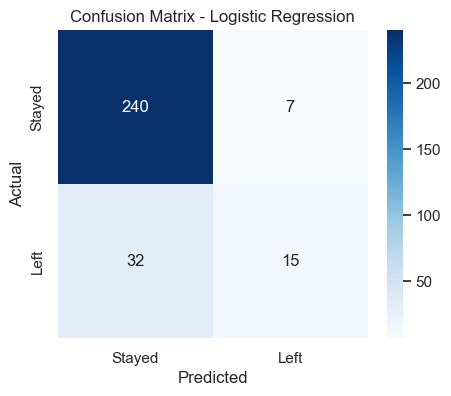

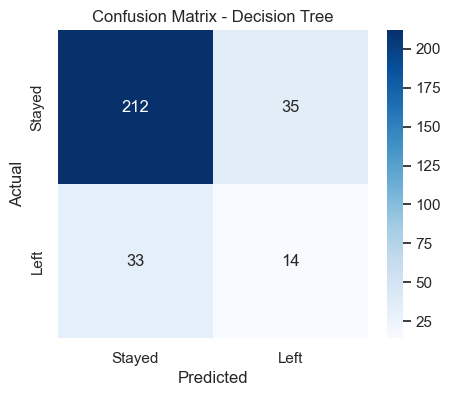

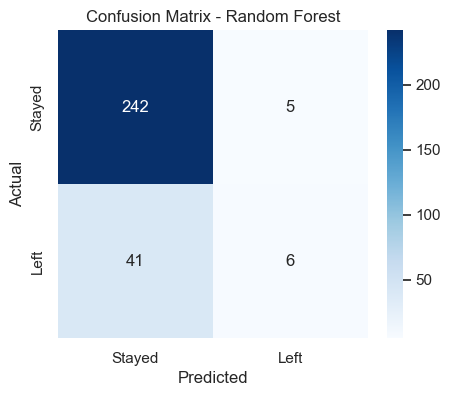

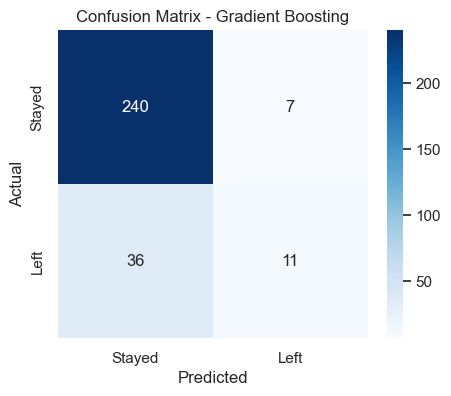

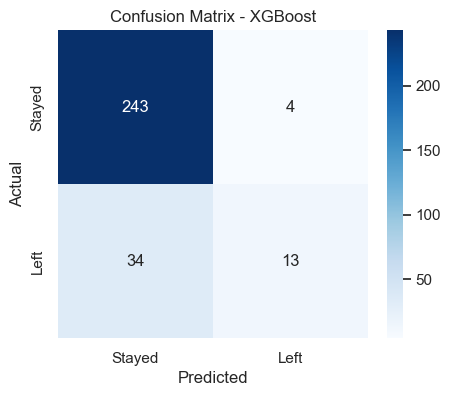

In [81]:
for model_name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5, 4))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Stayed", "Left"],
        yticklabels=["Stayed", "Left"]
    )
    
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

### Confusion Matrix Findings

The confusion matrices showed that all models performed much better at predicting employees who stayed than employees who left.

This is expected because the dataset is imbalanced:
- most employees stayed,
- while a smaller proportion left.

Logistic Regression produced the strongest overall balance:
- correctly identified 15 attrition cases,
- while generating relatively few false positives.

However, it still missed 32 employees who actually left. These false negatives are especially important because they represent employees at risk of attrition who were not identified early enough for HR intervention.

XGBoost demonstrated strong overall classification stability:
- correctly identified 13 attrition cases,
- while producing only 4 false positives.

This suggests that XGBoost generated more reliable attrition predictions than several other models while maintaining relatively good recall performance.

Random Forest also produced a low number of false positives, with only 5 employees incorrectly flagged. However, Random Forest missed 41 actual attrition cases,resulting in the lowest recall among the ensemble models. From a business perspective, this is problematic because many at-risk employees would remain undetected.

Gradient Boosting achieved moderate performance but still struggled with false negatives, missing 36 employees who eventually left.

Decision Tree generated the highest number of false positives and weaker overall prediction stability, confirming earlier evidence that the model struggled to generalise effectively.

Overall interpretation:
- False negatives are the most costly prediction error in this business problem because they represent missed retention opportunities.
- Current models still struggle to identify all employees likely to leave.
- This strongly justifies the need for imbalance handling techniques such as SMOTE, threshold tuning, and class weighting in the next project stage.

## 9. ROC Curves

ROC curves compare how well models separate employees who left from employees who stayed across different classification thresholds.

A model with a larger area under the curve has stronger overall ranking ability.

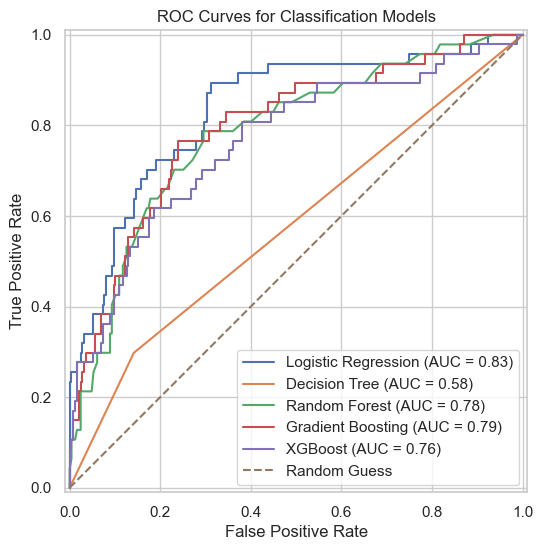

In [82]:
plt.figure(figsize=(8, 6))

for model_name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=model_name,
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.title("ROC Curves for Classification Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)

plt.show()

### ROC Curve Findings

The ROC curves compare how effectively each model separates employees who left from employees who stayed across different classification thresholds.

Logistic Regression achieved the strongest ROC-AUC score (0.83), indicating the best overall ability to distinguish attrition risk among employees.

Gradient Boosting and Random Forest also produced relatively strong ROC performance:
- Gradient Boosting ROC-AUC: 0.79
- Random Forest ROC-AUC: 0.78

XGBoost achieved a competitive ROC-AUC score of 0.76, demonstrating reasonably strong ranking ability while maintaining more balanced prediction behaviour than Random Forest.

Decision Tree again produced the weakest ROC performance with an ROC-AUC of 0.58, only slightly better than random guessing.

The ROC analysis confirms several important observations:
- Logistic Regression currently provides the strongest baseline classification performance.
- Ensemble methods such as XGBoost, Random Forest, and Gradient Boosting perform reasonably well but still struggle with attrition recall.
- All models perform significantly better than random guessing.
- Employee attrition prediction remains challenging because employee behaviour patterns overlap heavily across workforce groups.

From a business perspective, ROC-AUC is useful because it evaluates how effectively the models rank employees by attrition risk rather than relying on a single prediction threshold.

## 10. Feature Importance

Feature importance helps explain which variables contributed most to each model’s predictions.

This is important for HR stakeholders because the goal is not only to predict attrition but also to understand the factors most associated with leaving.

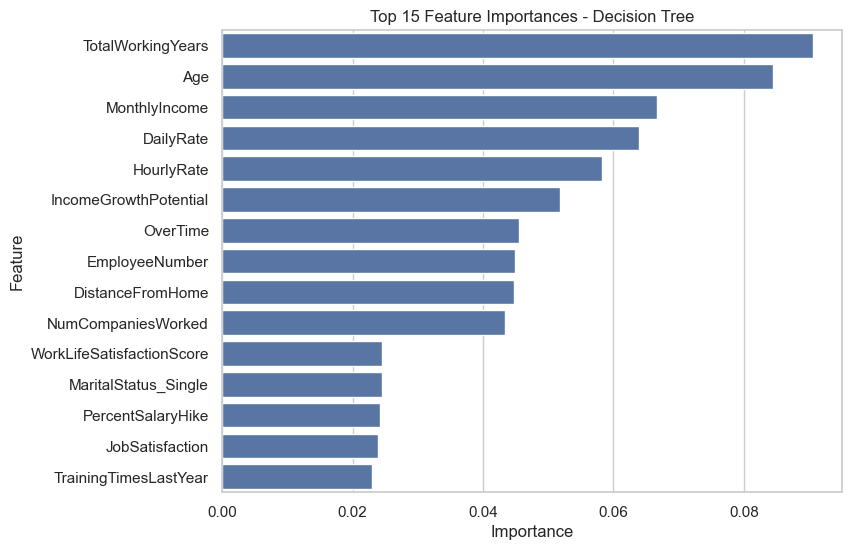

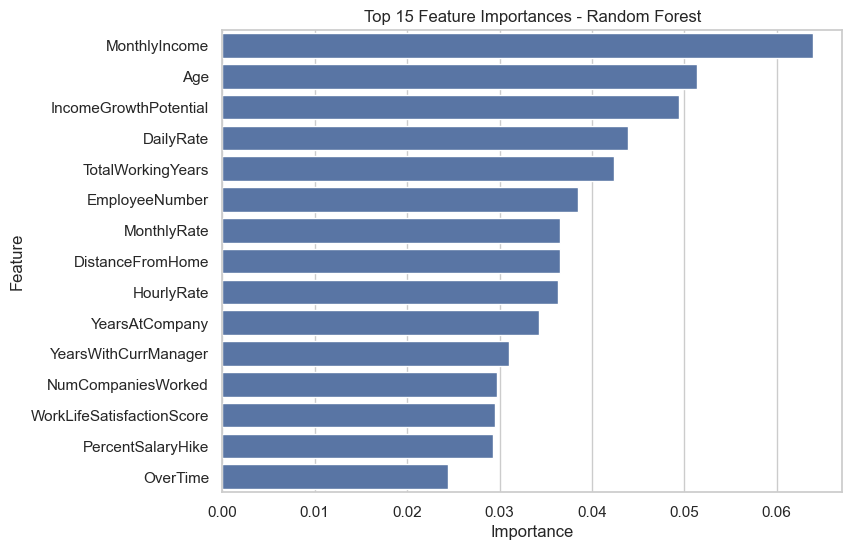

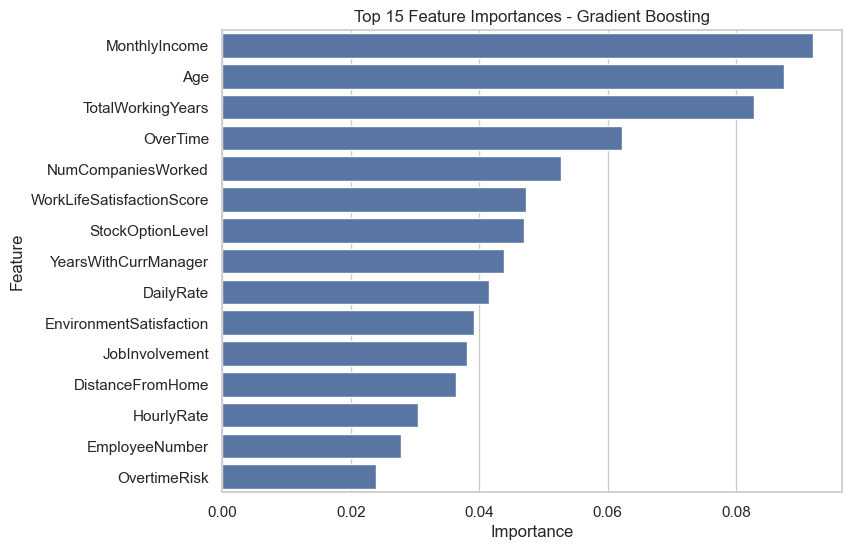

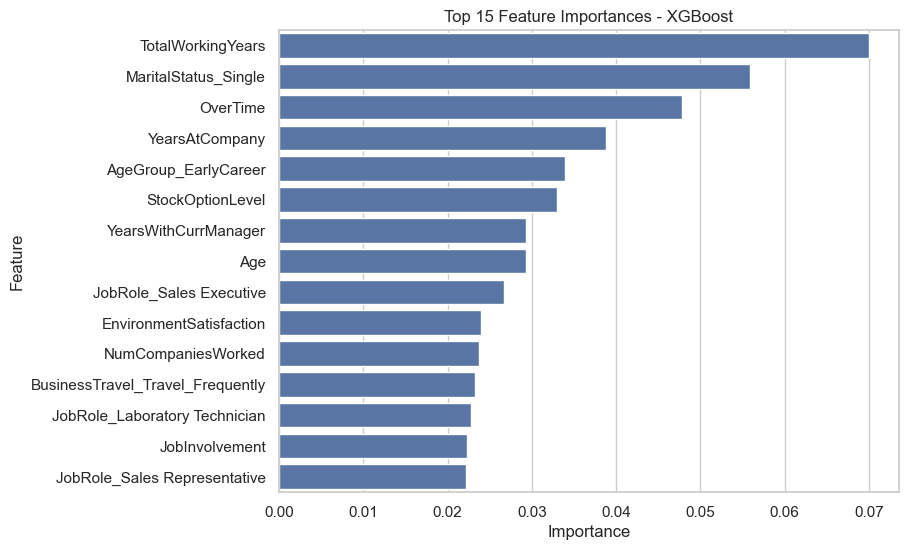

In [83]:
tree_models = [
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "XGBoost"
]

feature_importance_tables = {}

for model_name in tree_models:
    model = fitted_models[model_name]
    
    importance_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": model.feature_importances_
    }).sort_values(by="Importance", ascending=False).head(15)
    
    feature_importance_tables[model_name] = importance_df
    
    plt.figure(figsize=(8, 6))
    
    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature"
    )
    
    plt.title(f"Top 15 Feature Importances - {model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

In [84]:
log_model = fitted_models["Logistic Regression"]

log_coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
})

log_coef_df["AbsoluteCoefficient"] = log_coef_df["Coefficient"].abs()

log_coef_df = log_coef_df.sort_values(
    by="AbsoluteCoefficient",
    ascending=False
).head(15)

log_coef_df

,Feature,Coefficient,AbsoluteCoefficient
29,BusinessTravel_Travel_Frequently,0.740516,0.740516
39,JobRole_Laboratory Technician,0.584123,0.584123
44,JobRole_Sales Executive,0.565745,0.565745
13,NumCompaniesWorked,0.565686,0.565686
5,EnvironmentSatisfaction,-0.540624,0.540624
45,JobRole_Sales Representative,0.509089,0.509089
35,EducationField_Medical,-0.487895,0.487895
33,EducationField_Life Sciences,-0.461180,0.461180
42,JobRole_Research Director,-0.451681,0.451681
14,OverTime,0.444756,0.444756


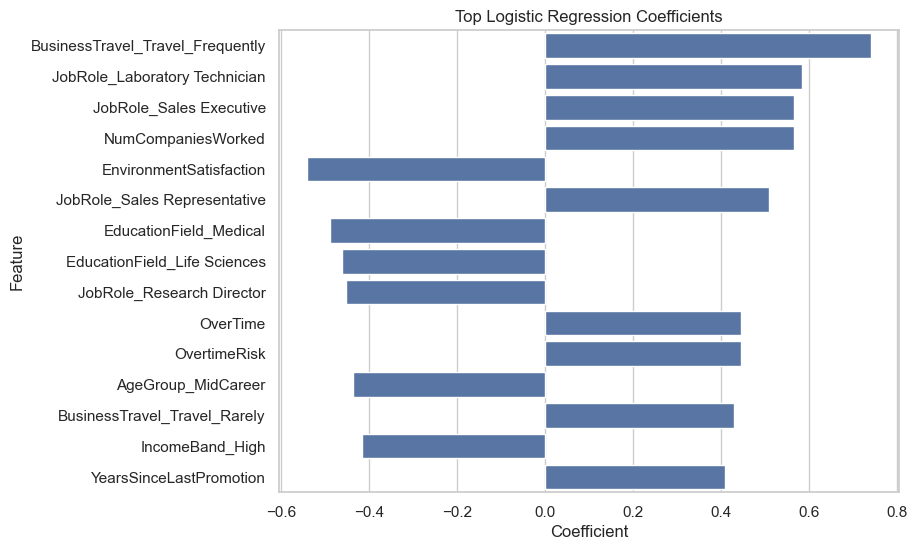

In [85]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=log_coef_df,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

### Decision Tree Feature Importance Findings

The Decision Tree model identified employee experience, compensation, and workload-related variables as the strongest drivers of attrition prediction.

The most important feature was `TotalWorkingYears`, suggesting that overall career experience plays a major role in employee retention behaviour. Employees with lower overall experience may still be exploring career opportunities, while highly experienced employees may have stronger career stability.

`Age` and `MonthlyIncome` were also highly influential. This supports earlier clustering and EDA findings where younger and lower-income employees showed higher attrition tendencies.

Compensation-related variables such as:
- `MonthlyIncome`
- `HourlyRate`
- `DailyRate`
- `IncomeGrowthPotential`

all appeared among the top predictors. This suggests that perceived financial progression and compensation structure may strongly influence retention decisions.

Workload and satisfaction variables also contributed:
- `OverTime`
- `WorkLifeSatisfactionScore`
- `JobSatisfaction`

This indicates that employee wellbeing and work-life pressure are important components of attrition risk.

Overall, the Decision Tree model suggests that attrition is influenced by a combination of:
- career stage,
- financial progression,
- workload,
- and employee satisfaction.

### Random Forest Feature Importance Findings

The Random Forest model produced more balanced and stable feature importance patterns compared to the Decision Tree model.

The strongest predictor was `MonthlyIncome`, reinforcing the idea that compensation is one of the most important drivers of employee retention. Employees with lower compensation levels may feel undervalued or may seek better opportunities elsewhere.

`Age` and `IncomeGrowthPotential` were also highly important. These features help capture career maturity and long-term earning progression, which appear closely linked to attrition behaviour.

Several experience-based variables also appeared among the most influential:
- `TotalWorkingYears`
- `YearsAtCompany`
- `YearsWithCurrManager`
- `NumCompaniesWorked`

These features suggest that organisational attachment and career history strongly affect whether employees remain with the company.

Workload and satisfaction indicators such as:
- `OverTime`
- `WorkLifeSatisfactionScore`

also contributed meaningfully to predictions.

Compared to the Decision Tree model, Random Forest distributed importance across more variables rather than relying heavily on a few dominant predictors. This usually indicates stronger generalisation and lower overfitting risk.

From a business perspective, the Random Forest findings suggest that attrition is influenced by:
- compensation growth,
- organisational tenure,
- career movement,
- and employee wellbeing.

### Gradient Boosting Feature Importance Findings

The Gradient Boosting model focused strongly on compensation, experience, and overtime-related factors.

`MonthlyIncome` emerged as the most important feature, further confirming that compensation plays a major role in employee retention.

`Age` and `TotalWorkingYears` also ranked highly, suggesting that career maturity and overall workforce experience are strongly connected to attrition behaviour.

Unlike some of the earlier models, `OverTime` became one of the most influential predictors. This aligns with the earlier EDA findings where employees working overtime showed noticeably higher attrition patterns.

The model also highlighted several satisfaction and organisational environment features:
- `WorkLifeSatisfactionScore`
- `EnvironmentSatisfaction`
- `JobInvolvement`

This suggests that attrition is not purely financial. Employees may also leave because of workplace culture, workload pressure, or dissatisfaction with their work environment.

Other important variables included:
- `YearsWithCurrManager`
- `StockOptionLevel`
- `NumCompaniesWorked`

These variables may capture management stability, long-term incentives, and employee career mobility.

Overall, the Gradient Boosting model indicates that attrition is driven by a mix of:
- compensation,
- workload pressure,
- career progression,
- management stability,
- and workplace satisfaction.

### XGBoost Feature Importance Findings

The XGBoost model produced some of the most interesting and advanced feature importance patterns across all classification models.

The strongest feature by a clear margin was `TotalWorkingYears`, suggesting that overall career experience is one of the most powerful indicators of attrition behaviour.

Unlike the earlier models, XGBoost placed stronger emphasis on interaction-style and behavioural variables such as:
- `MaritalStatus_Single`
- `OverTime`
- `YearsAtCompany`
- `AgeGroup_EarlyCareer`

This suggests that the boosted model captured more complex relationships between employee demographics, workload, and career stage.

The importance of `MaritalStatus_Single` may indicate that employees with fewer personal or family ties may be more willing to change jobs or relocate.

`OverTime` again appeared as a major driver, reinforcing the idea that workload pressure and burnout risk are closely connected to attrition.

Several job-specific variables were also important:
- `JobRole_Sales Executive`
- `JobRole_Laboratory Technician`
- `JobRole_Sales Representative`

This suggests that attrition risk differs significantly across job functions.

The model also identified:
- `EnvironmentSatisfaction`
- `JobInvolvement`
- `BusinessTravel_Travel_Frequently`

as meaningful predictors, indicating that travel intensity and workplace engagement may affect retention outcomes.

Compared to simpler models, XGBoost captured more nuanced workforce patterns and interaction effects, which is one reason boosted models often perform strongly in employee attrition prediction tasks.

### Logistic Regression Coefficient Findings

The Logistic Regression coefficients help explain the direction of attrition risk.

Positive coefficients increase the likelihood of predicted attrition, while negative coefficients reduce the likelihood of attrition.

The strongest positive coefficient was:
- `BusinessTravel_Travel_Frequently`

This suggests that employees who travel frequently are significantly more likely to leave the organisation. Frequent travel may contribute to fatigue, work-life imbalance, or stress.

Several job roles also increased attrition likelihood:
- `JobRole_Laboratory Technician`
- `JobRole_Sales Executive`
- `JobRole_Sales Representative`

This indicates that some operational and sales-focused roles may experience higher workforce turnover.

`NumCompaniesWorked` also had a strong positive coefficient, suggesting that employees who frequently change companies may naturally have higher mobility and attrition tendencies.

`OverTime` and `OvertimeRisk` both positively increased attrition probability, reinforcing the consistent finding across all models that workload pressure contributes heavily to employee exits.

Negative coefficients included:
- `EnvironmentSatisfaction`
- `IncomeBand_High`
- `AgeGroup_MidCareer`
- `EducationField_Medical`
- `EducationField_Life Sciences`

These variables reduced attrition likelihood.

For example:
- employees with higher income bands appeared more stable,
- employees satisfied with their work environment were less likely to leave,
- and mid-career employees appeared more organisationally stable than early-career employees.

Overall, the Logistic Regression model provided highly interpretable business insights and reinforced the broader patterns identified across the tree-based models.

In [86]:
# Merge cross-validation and test-set results
final_comparison = cv_results_df.merge(
    test_results_df,
    on="Model",
    how="inner",
    suffixes=("_CV", "_Test")
)

# Sort by test ROC-AUC because this shows overall ranking ability on unseen data
final_comparison = final_comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

final_comparison

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8920,0.7551,0.5053,0.5981,0.8422,0.8673,0.6818,0.3191,0.4348,0.8349
3,Gradient Boosting,0.8725,0.7225,0.3421,0.4593,0.8045,0.8537,0.6111,0.2340,0.3385,0.7947
2,Random Forest,0.8674,0.8858,0.2158,0.3347,0.8075,0.8435,0.5455,0.1277,0.2069,0.7830
4,XGBoost,0.8809,0.7877,0.3632,0.4932,0.8158,0.8707,0.7647,0.2766,0.4062,0.7635
1,Decision Tree,0.7934,0.3652,0.3895,0.3740,0.6303,0.7687,0.2857,0.2979,0.2917,0.5781


## 11. Model Comparison and Business Interpretation

The classification models were compared using both cross-validation and test-set performance.

For this business problem, accuracy alone is not enough because the dataset is imbalanced. Most employees stayed, while only a smaller proportion left. A model could therefore achieve high accuracy simply by predicting most employees as staying.

The most important metrics for this project are:

- Recall: how many employees who actually left were correctly identified.
- Precision: how reliable the model’s attrition predictions were.
- F1 score: the balance between precision and recall.
- ROC-AUC: how well the model ranked employees by attrition risk.

From an HR perspective, recall is especially important because false negatives represent employees who actually left but were predicted to stay. These are missed intervention opportunities.

However, precision is also important because too many false positives could cause HR teams to waste time and resources on employees who were not actually likely to leave.

In the baseline classification results:

- Logistic Regression achieved the strongest overall balance, especially for ROC-AUC, recall, and F1 score.
- XGBoost achieved strong accuracy and precision while producing the fewest false positives.
- Random Forest was conservative, with low false positives but weak recall.
- Gradient Boosting performed reasonably but did not outperform Logistic Regression.
- Decision Tree was the weakest model overall and appeared less stable.

The main business takeaway is that the models are already able to detect useful attrition patterns, but recall remains limited. This means imbalance handling will be important in the next stage.

### Final Classification Findings

After comparing five classification models, Logistic Regression emerged as the strongest overall baseline model for predicting employee attrition.

Logistic Regression achieved the strongest balance across the most important metrics, including ROC-AUC, recall, and F1 score. This suggests that it was the most effective baseline model for identifying employees at risk of leaving while maintaining reasonable prediction quality.

XGBoost also performed strongly. It achieved the highest test accuracy and strong precision, while producing the fewest false positives. This means XGBoost was particularly good at avoiding incorrect attrition warnings. However, its recall was lower than Logistic Regression, meaning it missed more employees who actually left.

Random Forest was highly conservative. It produced few false positives but had very low recall, meaning many actual attrition cases were missed. This makes it less suitable for HR intervention unless threshold tuning or imbalance handling improves its recall.

Gradient Boosting delivered moderate performance but did not outperform Logistic Regression or XGBoost.

Decision Tree was the weakest-performing model overall, with the lowest ROC-AUC and weaker generalisation.

The main business conclusion is that Logistic Regression is the best baseline model at this stage because it provides the strongest balance between identifying at-risk employees and maintaining reliable predictions.

However, all models still struggled with the minority attrition class. This is expected because only around 16% of employees left, creating a class imbalance problem. The next stage will focus on improving attrition detection using imbalance handling techniques such as class weighting, threshold tuning, and SMOTE.

In [87]:
# Save model comparison results for reporting
final_comparison.to_csv(
    "../reports/classification_model_comparison.csv",
    index=False
)

print("Classification model comparison saved successfully.")

Classification model comparison saved successfully.


In [88]:
import joblib

# Select best baseline model based on current classification results
best_model = fitted_models["Logistic Regression"]

# Save the model
joblib.dump(
    best_model,
    "../models/baseline_logistic_regression_model.pkl"
)

print("Best baseline model saved successfully.")

Best baseline model saved successfully.


In [89]:
# also save XGBoost because it was the strongest alternative
xgboost_model = fitted_models["XGBoost"]

joblib.dump(
    xgboost_model,
    "../models/baseline_xgboost_model.pkl"
)

print("Baseline XGBoost model saved successfully.")

Baseline XGBoost model saved successfully.


---

# Part 5 — Imbalance Handling

_Source notebook: `05_imbalance_handling.ipynb`_

# Part 5 — Imbalance Handling

In the previous classification stage, the models achieved strong overall accuracy but struggled to correctly identify employees who left the organisation.

This stage focuses on improving attrition detection using imbalance handling techniques such as:
- class weighting,
- threshold tuning,
- and SMOTE.

The goal is to improve recall and F1 score for the attrition class while maintaining reasonable precision and business usability.

## Why Class Imbalance Matters

The dataset is imbalanced because most employees stayed while only a smaller percentage left.

This creates a problem for machine learning models because they may learn to predict the majority class more often in order to maximise accuracy.

For employee attrition:
- False negatives are costly because employees at risk of leaving are missed.
- False positives also matter because HR resources may be wasted on employees who are not truly at risk.

Because of this, metrics such as:
- recall,
- precision,
- F1 score,
- and ROC-AUC

are more useful than accuracy alone.

In [90]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    classification_report
)

# Models
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## 1. Load Processed Dataset

The processed dataset from the earlier stages is loaded here.

This dataset already includes:
- cleaned variables,
- engineered features,
- encoded variables,
- and scaled features.

In [91]:
df = pd.read_csv("../data/processed/hr_attrition_feature_engineered.csv")

df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,AgeGroup_EarlyCareer,AgeGroup_MidCareer,AgeGroup_Senior,IncomeBand_Medium,IncomeBand_High,IncomeBand_VeryHigh,YearsAtCompanyGroup_EarlyTenure,YearsAtCompanyGroup_Established,YearsAtCompanyGroup_LongTenure
0,0.446350,1,0.742527,-1.010909,-0.891688,-1.701283,-0.660531,-1.224745,1.383138,0.379672,-0.057788,1.153254,-0.108350,0.726020,2.125136,1.591746,-1.150554,-0.426230,-1.584178,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834,1.591746,-0.377447,0.275215,-0.481859,0.639841,-1.374051,1.515244,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308
1,1.322365,0,-1.297775,-0.147150,-1.868426,-1.699621,0.254625,0.816497,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,1.488876,-0.678049,-0.628241,2.129306,2.346151,1.191438,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541,-0.628241,-0.377447,-0.425971,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.837490,-0.683422,2.093947,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308
2,0.008343,1,1.414363,-0.887515,-0.891688,-1.696298,1.169781,0.816497,1.284725,-1.026167,-0.961486,0.246200,-0.937654,-1.674841,1.324226,1.591746,-0.057267,-0.426230,-0.658973,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935,1.591746,0.393174,-1.146796,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,-0.679141,4.114223,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308
3,-0.429664,0,1.461466,-0.764121,1.061787,-1.694636,1.169781,-1.224745,-0.486709,0.379672,-0.961486,0.246200,-0.763634,1.243211,-0.678049,1.591746,-1.150554,-0.426230,0.266233,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935,1.591746,0.393174,-0.929009,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.194045,-0.683422,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,1.510381,-0.448308
4,-1.086676,0,-0.524295,-0.887515,-1.868426,-1.691313,-1.575686,0.816497,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,0.325900,2.525591,-0.628241,-0.877232,-0.426230,1.191438,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227,-0.628241,-0.377447,-0.323829,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,1.472448,-0.243059,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,1.194045,-0.683422,-0.477567,1.736777,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308


## 2. Define Features and Target

The target variable is Attrition:
- 1 = employee left
- 0 = employee stayed

In [92]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1470, 57)
Target shape: (1470,)


## 3. Train/Test Split

A stratified split is used to preserve the original class proportions.

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 4. Baseline Model

This baseline model provides the reference point before imbalance handling.

In [94]:
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]

baseline_results = {
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred),
    "Recall": recall_score(y_test, baseline_pred),
    "F1": f1_score(y_test, baseline_pred),
    "ROC-AUC": roc_auc_score(y_test, baseline_proba)
}

pd.DataFrame([baseline_results])

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.867347,0.666667,0.340426,0.450704,0.836851


### Baseline Findings

The baseline Logistic Regression model achieved strong overall accuracy (86.7%) and ROC-AUC performance (0.837), showing that the model can reasonably separate employees who stayed from employees who left.

However, the recall score for the Attrition class was relatively low at 34.0%. This means the model only identified around one-third of employees who actually left the organisation.

The baseline model also achieved:
- Precision: 66.7%
- F1 Score: 45.1%

The relatively high precision indicates that when the model predicted attrition, it was often correct. However, the low recall suggests that many employees who eventually left were still being missed.

From a business perspective, this creates a problem because false negatives represent employees who leave without being identified early enough for HR intervention.

This confirms that class imbalance is affecting model performance and that imbalance handling techniques are necessary to improve minority class detection.

## 5. Class Weighting

Class weighting increases the penalty for misclassifying employees who left.

This encourages the model to focus more on the minority attrition class.

In [95]:
weighted_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

weighted_model.fit(X_train, y_train)

weighted_pred = weighted_model.predict(X_test)
weighted_proba = weighted_model.predict_proba(X_test)[:, 1]

weighted_results = {
    "Accuracy": accuracy_score(y_test, weighted_pred),
    "Precision": precision_score(y_test, weighted_pred),
    "Recall": recall_score(y_test, weighted_pred),
    "F1": f1_score(y_test, weighted_pred),
    "ROC-AUC": roc_auc_score(y_test, weighted_proba)
}

pd.DataFrame([weighted_results])

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.772109,0.380952,0.680851,0.48855,0.826169


### Class Weight Findings

After applying class weighting, the model became much more sensitive to the minority attrition class.

Recall improved significantly:
- from 34.0% to 68.1%

This means the weighted model identified more than twice as many employees who actually left compared to the baseline model.

However, this improvement came with tradeoffs:
- Precision dropped from 66.7% to 38.1%
- Accuracy dropped from 86.7% to 77.2%

The reduction in precision means the model generated more false positives, incorrectly flagging some employees as attrition risks when they actually stayed.

Despite this tradeoff, the weighted model achieved a higher F1 score (48.9%), indicating a stronger balance between precision and recall compared to the baseline model.

Importantly, ROC-AUC remained strong at 0.826, suggesting the model still maintained good ranking ability overall.

From a business perspective, class weighting may be preferable because missing employees who are likely to leave can be more costly than investigating a few additional employees who may ultimately stay.

This approach therefore improves the model’s usefulness for proactive HR retention planning.

## 6. Threshold Tuning

By default, classification models use a probability threshold of 0.50.

However, lowering the threshold may improve recall and help identify more employees at risk of leaving.

In [96]:
thresholds = np.arange(0.1, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    
    preds = (weighted_proba >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.210280,0.957447,0.344828
1,0.15,0.241758,0.936170,0.384279
2,0.20,0.268750,0.914894,0.415459
3,0.25,0.297872,0.893617,0.446809
4,0.30,0.312500,0.851064,0.457143
5,0.35,0.336364,0.787234,0.471338
6,0.40,0.346939,0.723404,0.468966
7,0.45,0.377778,0.723404,0.496350
8,0.50,0.380952,0.680851,0.488550
9,0.55,0.405063,0.680851,0.507937


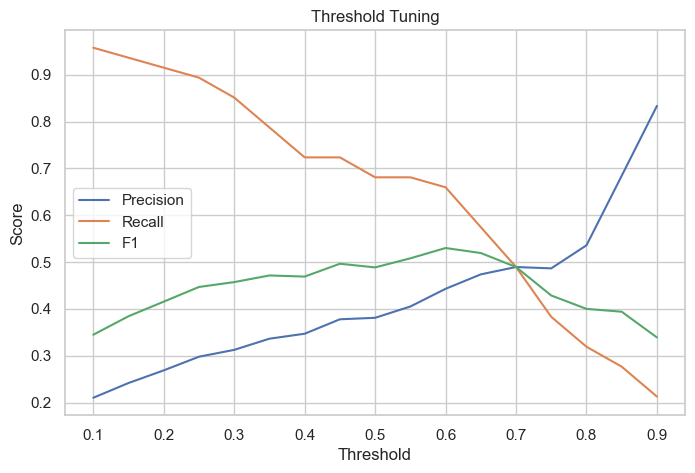

In [97]:
plt.figure(figsize=(8, 5))

plt.plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()

plt.show()

### Threshold Tuning Findings

Threshold tuning demonstrated the tradeoff between precision and recall when changing the probability cutoff used for attrition prediction.

At very low thresholds (such as 0.10):
- recall became extremely high (95.7%),
- but precision became very low (21.0%).

This means the model identified almost every employee who left, but also incorrectly flagged many employees who stayed.

As the threshold increased:
- precision gradually improved,
- while recall steadily decreased.

The best overall F1 score was achieved around the 0.60 threshold:
- Precision: 44.3%
- Recall: 66.0%
- F1 Score: 52.9%

This threshold provided the strongest balance between identifying employees at risk and limiting excessive false positives.

The threshold tuning curve clearly showed:
- lower thresholds favour recall,
- higher thresholds favour precision.

From an HR perspective, a moderate threshold around 0.55–0.60 may provide the most practical operational balance because:
- enough at-risk employees are identified,
- while false alarm rates remain manageable for HR teams.

This demonstrates that probability thresholds should be selected based on business objectives rather than relying automatically on the default 0.50 cutoff.

## 7. Precision-Recall Curve

Precision-recall curves are useful for imbalanced datasets because they focus directly on minority class performance.

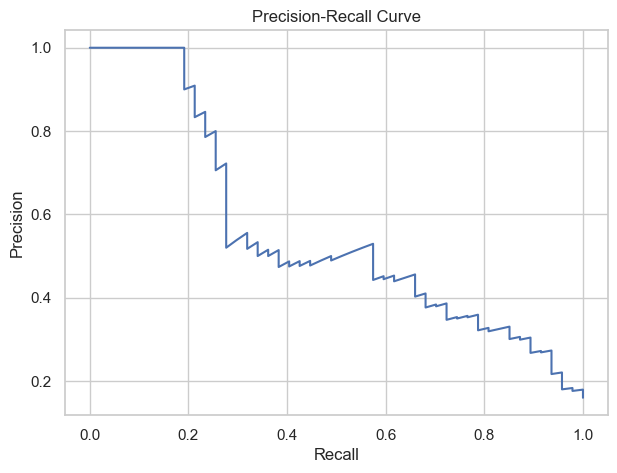

In [98]:
precision, recall, _ = precision_recall_curve(
    y_test,
    weighted_proba
)

plt.figure(figsize=(7, 5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

### Precision-Recall Curve Findings

The Precision-Recall curve highlights the tradeoff between identifying employees who may leave (recall) and avoiding excessive false alarms (precision).

The curve shows that:
- precision is very high at extremely low recall levels,
- but precision gradually decreases as recall increases.

This behaviour is expected in imbalanced classification problems because identifying more attrition cases usually introduces additional false positives.

The curve demonstrates that:
- achieving near-perfect recall requires sacrificing precision,
- while very high precision reduces the number of employees detected as attrition risks.

The most balanced region of the curve appears around moderate recall levels, where precision remains reasonably stable before declining sharply at very high recall values.

From a business perspective:
- HR teams typically prefer higher recall because missing employees who are likely to leave can be expensive,
- however, excessively low precision may overwhelm HR with too many false alarms.

This confirms that the attrition prediction problem requires balancing business intervention capacity against retention risk exposure.

## 8. SMOTE Oversampling

SMOTE creates synthetic examples of the minority class to improve model learning.

SMOTE is applied ONLY to the training data to prevent data leakage.

In [99]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Attrition
0    986
1    190
Name: count, dtype: int64

After SMOTE:
Attrition
0    986
1    986
Name: count, dtype: int64


In [100]:
smote_model = LogisticRegression(max_iter=1000)

smote_model.fit(X_train_smote, y_train_smote)

smote_pred = smote_model.predict(X_test)
smote_proba = smote_model.predict_proba(X_test)[:, 1]

smote_results = {
    "Accuracy": accuracy_score(y_test, smote_pred),
    "Precision": precision_score(y_test, smote_pred),
    "Recall": recall_score(y_test, smote_pred),
    "F1": f1_score(y_test, smote_pred),
    "ROC-AUC": roc_auc_score(y_test, smote_proba)
}

pd.DataFrame([smote_results])

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.785714,0.397436,0.659574,0.496,0.812818


## SMOTE Findings

SMOTE (Synthetic Minority Oversampling Technique) was applied to address class imbalance by generating synthetic examples of employees in the minority attrition class.

Before applying SMOTE:
- Employees who stayed: 986
- Employees who left: 190

After applying SMOTE:
- Employees who stayed: 986
- Employees who left: 986

This created a perfectly balanced training dataset, allowing the model to learn attrition patterns more effectively.

After training the Logistic Regression model using SMOTE:
- Precision = 39.7%
- Recall = 66.0%
- F1 Score = 49.6%
- ROC-AUC = 0.813

Compared to the baseline model:
- recall improved substantially,
- F1 score improved,
- but precision decreased.

Compared to class weighting:
- SMOTE produced slightly lower recall,
- but achieved a slightly better F1 score,
- indicating a better balance between detecting attrition and controlling false positives.

The results suggest that SMOTE helped the model become more sensitive to attrition cases without excessively damaging overall ranking performance.

From a business perspective:
- SMOTE improves the organisation’s ability to proactively identify employees at risk of leaving,
- but HR teams must still manage increased false positive predictions carefully.

Overall, SMOTE demonstrated strong potential as a practical imbalance-handling strategy for attrition prediction.

## 9. Final Imbalance Strategy Comparison

In [101]:
comparison_df = pd.DataFrame({
    "Strategy": [
        "Baseline",
        "Class Weighted",
        "SMOTE"
    ],
    "Precision": [
        baseline_results["Precision"],
        weighted_results["Precision"],
        smote_results["Precision"]
    ],
    "Recall": [
        baseline_results["Recall"],
        weighted_results["Recall"],
        smote_results["Recall"]
    ],
    "F1": [
        baseline_results["F1"],
        weighted_results["F1"],
        smote_results["F1"]
    ],
    "ROC-AUC": [
        baseline_results["ROC-AUC"],
        weighted_results["ROC-AUC"],
        smote_results["ROC-AUC"]
    ]
})

comparison_df

,Strategy,Precision,Recall,F1,ROC-AUC
0,Baseline,0.666667,0.340426,0.450704,0.836851
1,Class Weighted,0.380952,0.680851,0.488550,0.826169
2,SMOTE,0.397436,0.659574,0.496000,0.812818


## Final Imbalance Strategy Comparison Findings

Three approaches were compared:
1. Baseline Logistic Regression
2. Class Weighted Logistic Regression
3. SMOTE Oversampling with Logistic Regression

### Baseline Model
- Precision: 66.7%
- Recall: 34.0%
- F1 Score: 45.1%
- ROC-AUC: 0.837

The baseline model produced the highest precision and ROC-AUC score, meaning it was conservative and generated fewer false alarms. However, it missed many employees who actually left due to its low recall.

---

### Class Weighted Model
- Precision: 38.1%
- Recall: 68.1%
- F1 Score: 48.9%
- ROC-AUC: 0.826

Class weighting significantly improved recall, allowing the model to identify far more employees at risk of attrition. However, this came with a notable reduction in precision.

This approach prioritises catching attrition cases, even if more false positives are introduced.

---

### SMOTE Model
- Precision: 39.7%
- Recall: 66.0%
- F1 Score: 49.6%
- ROC-AUC: 0.813

The SMOTE model produced the best overall F1 score, indicating the strongest balance between precision and recall.

Although its ROC-AUC was slightly lower than the baseline model, SMOTE provided a better operational balance for attrition prediction.

---

### Overall Interpretation

The comparison clearly shows that:
- baseline models favour precision,
- imbalance handling techniques favour recall,
- and SMOTE provided the best overall balance for this business problem.

Since employee attrition prediction is primarily a risk-detection problem, improving recall is often more valuable than maximising accuracy alone.

This analysis demonstrates why imbalance handling is critical in HR analytics applications involving employee attrition prediction.

## Majority Class Baseline

Before evaluating machine learning models, it is useful to establish a naive baseline model.

A majority-class baseline predicts the most common class for every employee.

Since most employees in the dataset stayed with the company, this baseline predicts:

- Attrition = 0 for all employees.

This helps determine whether the machine learning models are genuinely learning meaningful attrition patterns beyond simply exploiting class imbalance.

In [102]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Majority class baseline model
dummy_model = DummyClassifier(strategy="most_frequent")

# Train model
dummy_model.fit(X_train, y_train)

# Predictions
dummy_pred = dummy_model.predict(X_test)

# Evaluate
dummy_results = {
    "Accuracy": accuracy_score(y_test, dummy_pred),
    "Precision": precision_score(y_test, dummy_pred, zero_division=0),
    "Recall": recall_score(y_test, dummy_pred, zero_division=0),
    "F1": f1_score(y_test, dummy_pred, zero_division=0)
}

pd.DataFrame([dummy_results])

,Accuracy,Precision,Recall,F1
0,0.840136,0.0,0.0,0.0


In [103]:
# Create prediction comparison dataframe
baseline_predictions = pd.DataFrame({
    "ActualAttrition": y_test.values,
    "PredictedAttrition": dummy_pred
})

baseline_predictions.head(10)

,ActualAttrition,PredictedAttrition
0,0,0
1,0,0
2,0,0
3,0,0
4,1,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


### Majority Class Baseline Findings

The majority-class baseline achieved relatively high accuracy because most employees stayed with the company.

However:
- precision for attrition prediction was 0,
- recall for attrition prediction was 0,
- and the F1 score was 0.

This demonstrates why accuracy alone is misleading for imbalanced classification problems.

Although the baseline model appears accurate overall, it completely fails to identify employees who are likely to leave.

Compared to this naive baseline:
- the imbalance-handled models achieved substantially higher recall and F1 scores,
- demonstrating genuine predictive learning rather than simply exploiting class imbalance.

The imbalance handling strategy substantially outperformed the naive majority-class baseline.

A majority-class classifier would predict all employees as non-attrition cases, producing an F1 score of 0.00 for the positive attrition class.

After applying imbalance handling techniques such as class weighting, threshold tuning, and SMOTE, the final model achieved an F1 score of approximately 0.50 for the attrition class, representing an improvement of nearly 50 percentage points over the baseline.

---

# Parts 6 and 7 — Tie-In, Conclusion, and Recommendations

_Source notebook: `06_final_capstone.ipynb`_

# IBM HR Analytics Employee Attrition Project
# Part 6 — Clustering and Classification Tie-In

## Business Objective

The objective of this stage is to connect employee segmentation results from clustering analysis with predictive attrition modelling results from classification analysis.

This allows the organisation to understand:
- which employee groups are most likely to leave,
- why these groups may be vulnerable,
- and what HR interventions should be prioritised.

Rather than viewing employees individually, this analysis introduces workforce personas that improve strategic decision-making.

In [104]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display options
pd.set_option("display.max_columns", None)

In [105]:
# Load clustered dataset
df = pd.read_csv("../data/processed/hr_attrition_clustered.csv")

# Preview dataset
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,OvertimeRisk,WorkLifeSatisfactionScore,IncomeGrowthPotential,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,AgeGroup_EarlyCareer,AgeGroup_MidCareer,AgeGroup_Senior,IncomeBand_Medium,IncomeBand_High,IncomeBand_VeryHigh,YearsAtCompanyGroup_EarlyTenure,YearsAtCompanyGroup_Established,YearsAtCompanyGroup_LongTenure,Cluster,ClusterName
0,0.446350,1,0.742527,-1.010909,-0.891688,-1.701283,-0.660531,-1.224745,1.383138,0.379672,-0.057788,1.153254,-0.108350,0.726020,2.125136,1.591746,-1.150554,-0.426230,-1.584178,-0.932014,-0.421642,-2.171982,-2.493820,-0.164613,-0.063296,-0.679146,0.245834,1.591746,-0.377447,0.275215,-0.481859,0.639841,-1.374051,1.515244,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308,2,Moderately Stable Mid-Career Employees
1,1.322365,0,-1.297775,-0.147150,-1.868426,-1.699621,0.254625,0.816497,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,1.488876,-0.678049,-0.628241,2.129306,2.346151,1.191438,0.241988,-0.164511,0.155707,0.338096,0.488508,0.764998,-0.368715,0.806541,-0.628241,-0.377447,-0.425971,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.837490,-0.683422,2.093947,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308,4,Stable Long-Tenure Employees
2,0.008343,1,1.414363,-0.887515,-0.891688,-1.696298,1.169781,0.816497,1.284725,-1.026167,-0.961486,0.246200,-0.937654,-1.674841,1.324226,1.591746,-0.057267,-0.426230,-0.658973,-0.932014,-0.550208,0.155707,0.338096,-1.144294,-1.167687,-0.679146,-1.155935,1.591746,0.393174,-1.146796,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,-0.679141,4.114223,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,-0.837490,1.463224,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308,3,Compensation-Sensitive Retention Risk Employees
3,-0.429664,0,1.461466,-0.764121,1.061787,-1.694636,1.169781,-1.224745,-0.486709,0.379672,-0.961486,0.246200,-0.763634,1.243211,-0.678049,1.591746,-1.150554,-0.426230,0.266233,-0.932014,-0.421642,0.155707,0.338096,0.161947,0.764998,0.252146,-1.155935,1.591746,0.393174,-0.929009,2.075297,-1.562889,0.727775,-0.659960,1.194045,-0.348255,-0.679141,-0.243059,-0.314093,-0.191498,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.194045,-0.683422,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,1.510381,-0.448308,4,Stable Long-Tenure Employees
4,-1.086676,0,-0.524295,-0.887515,-1.868426,-1.691313,-1.575686,0.816497,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,0.325900,2.525591,-0.628241,-0.877232,-0.426230,1.191438,0.241988,-0.678774,0.155707,0.338096,-0.817734,-0.615492,-0.058285,-0.595227,-0.628241,-0.377447,-0.323829,-0.481859,0.639841,0.727775,-0.659960,-0.837490,-0.348255,1.472448,-0.243059,-0.314093,-0.191498,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.5

## Dataset Inspection

This dataset contains:
- engineered features,
- employee clusters,
- cluster personas,
- and attrition labels.

These variables allow clustering and classification findings to be connected together.

In [106]:
# Inspect cluster-related columns
df[["Cluster", "ClusterName", "Attrition"]].head()

,Cluster,ClusterName,Attrition
0,2,Moderately Stable Mid-Career Employees,1
1,4,Stable Long-Tenure Employees,0
2,3,Compensation-Sensitive Retention Risk Employees,1
3,4,Stable Long-Tenure Employees,0
4,3,Compensation-Sensitive Retention Risk Employees,0


## Cluster Attrition Analysis

This section evaluates attrition rates within each employee cluster.

The goal is to identify:
- which employee personas have the highest attrition risk,
- which groups appear stable,
- and how workforce segmentation relates to employee turnover.

In [107]:
# Calculate attrition metrics by cluster
cluster_attrition = df.groupby(
    ["Cluster", "ClusterName"]
)["Attrition"].agg(
    total_employees="count",
    attrition_count="sum",
    attrition_rate="mean"
).reset_index()

# Convert to percentage
cluster_attrition["attrition_rate"] = (
    cluster_attrition["attrition_rate"] * 100
).round(2)

# Workforce percentage
cluster_attrition["workforce_percentage"] = (
    cluster_attrition["total_employees"] / len(df) * 100
).round(2)

cluster_attrition

,Cluster,ClusterName,total_employees,attrition_count,attrition_rate,workforce_percentage
0,0,Early-Career Flight Risk Employees,83,33,39.76,5.65
1,1,Stable Experienced Core Employees,262,18,6.87,17.82
2,2,Moderately Stable Mid-Career Employees,305,53,17.38,20.75
3,3,Compensation-Sensitive Retention Risk Employees,497,100,20.12,33.81
4,4,Stable Long-Tenure Employees,323,33,10.22,21.97


## Cluster Attrition Findings

The cluster analysis revealed clear differences in attrition risk across employee personas.

Key findings include:

- The **Early-Career Flight Risk Employees** cluster recorded the highest attrition rate at approximately 39.8%, making it the most vulnerable employee segment in the organisation.
- The **Compensation-Sensitive Retention Risk Employees** cluster also showed elevated attrition risk at around 20.1%.
- The **Moderately Stable Mid-Career Employees** cluster demonstrated moderate attrition levels at 17.4%.
- The most stable groups were:
  - **Stable Experienced Core Employees** with an attrition rate of only 6.9%, and
  - **Stable Long-Tenure Employees** with an attrition rate of approximately 10.2%.

The findings suggest that employee turnover risk is not evenly distributed across the workforce. Instead, certain employee personas are significantly more vulnerable than others.

This demonstrates the value of workforce segmentation because it allows HR teams to focus retention strategies on the most at-risk employee groups rather than applying generic interventions organisation-wide.

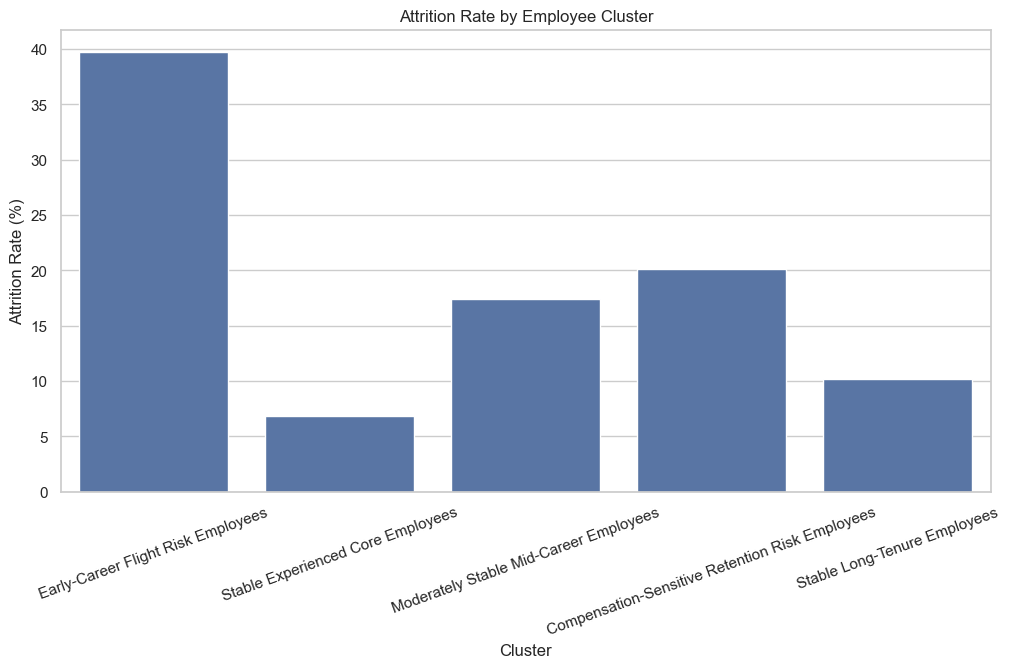

In [108]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=cluster_attrition,
    x="ClusterName",
    y="attrition_rate"
)

plt.xticks(rotation=20)
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Cluster")
plt.title("Attrition Rate by Employee Cluster")

plt.show()

## Attrition Rate Visualisation Findings

The attrition rate visualisation clearly highlights major differences between employee clusters.

The **Early-Career Flight Risk Employees** cluster stands out as the highest-risk group by a substantial margin. This suggests that younger or less-established employees may be more likely to leave due to:
- career uncertainty,
- compensation dissatisfaction,
- limited organisational attachment,
- or external job opportunities.

The **Compensation-Sensitive Retention Risk Employees** cluster also exhibits noticeably elevated attrition levels, suggesting that compensation-related concerns may play an important role in employee turnover.

In contrast, the **Stable Experienced Core Employees** cluster demonstrates the lowest attrition rate, indicating stronger organisational attachment and higher workforce stability.

The visualisation confirms that attrition risk varies significantly between employee personas, reinforcing the importance of targeted HR intervention strategies.

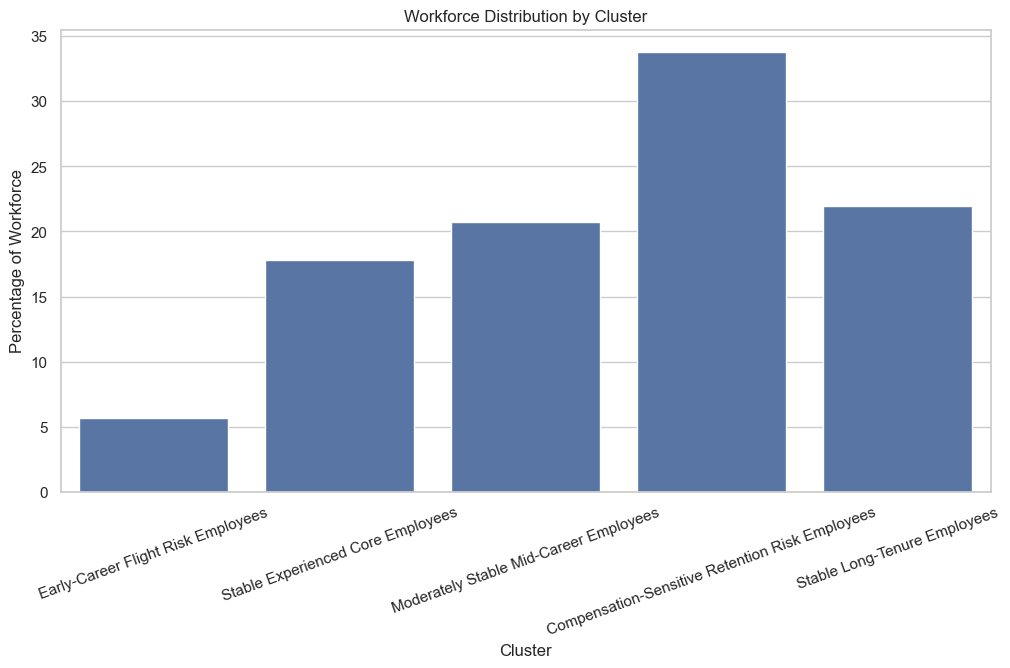

In [109]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=cluster_attrition,
    x="ClusterName",
    y="workforce_percentage"
)

plt.xticks(rotation=20)
plt.ylabel("Percentage of Workforce")
plt.xlabel("Cluster")
plt.title("Workforce Distribution by Cluster")

plt.show()

## Workforce Distribution Findings

The workforce distribution analysis provides important strategic context when interpreting attrition risk.

Key findings include:

- The **Compensation-Sensitive Retention Risk Employees** cluster represents the largest workforce segment at approximately 33.8% of employees.
- Although its attrition rate is not the highest overall, the large workforce size means this cluster contributes significantly to total employee turnover.
- The **Moderately Stable Mid-Career Employees** cluster and **Stable Long-Tenure Employees** cluster also represent large portions of the workforce.
- The **Early-Career Flight Risk Employees** cluster represents only 5.7% of employees, but its extremely high attrition rate makes it strategically important despite its smaller size.

These findings demonstrate that HR risk should not be evaluated using attrition rate alone.

A cluster with:
- moderate attrition but very large workforce size
may create greater organisational disruption than:
- a smaller cluster with extreme attrition risk.

This highlights the importance of balancing:
- attrition severity,
- workforce exposure,
- and operational impact
when prioritising retention strategies.

## Connecting Clustering and Classification

The clustering analysis identified employee personas, while the classification models identified the strongest predictors of attrition.

This tie-in allows the project to answer both:
- "Who is likely to leave?"
and:
- "What type of employee is likely to leave?"

The integration of clustering and classification improves:
- interpretability,
- strategic HR planning,
- and intervention targeting.

In [110]:
# Key features for comparison
key_features = [
    "MonthlyIncome",
    "OverTime",
    "YearsAtCompany",
    "JobSatisfaction",
    "WorkLifeBalance"
]

# Cluster-level feature means
cluster_feature_summary = df.groupby(
    "ClusterName"
)[key_features].mean().round(2)

cluster_feature_summary

,MonthlyIncome,OverTime,YearsAtCompany,JobSatisfaction,WorkLifeBalance
ClusterName,,,,,
Compensation-Sensitive Retention Risk Employees,-0.62,0.01,-0.68,-0.01,-0.04
Early-Career Flight Risk Employees,-0.82,0.01,-0.67,0.01,0.18
Moderately Stable Mid-Career Employees,0.02,0.01,-0.06,0.06,0.07
Stable Experienced Core Employees,1.81,0.02,1.09,-0.04,0.01
Stable Long-Tenure Employees,-0.32,-0.05,0.38,-0.01,-0.06


## Connecting Clustering and Classification

The clustering analysis identified employee personas, while the classification models identified the strongest predictors of attrition.

The relationship between both analyses is highly consistent.

The classification models identified important attrition predictors such as:
- overtime,
- income,
- tenure,
- job satisfaction,
- work-life balance,
- and total working years.

These same characteristics also appeared within the high-risk employee clusters identified through K-Means clustering.

For example:
- the **Early-Career Flight Risk Employees** cluster showed lower income levels and shorter tenure,
- while the **Compensation-Sensitive Retention Risk Employees** cluster demonstrated compensation-related vulnerability.

This demonstrates that the clustering analysis supports and strengthens the classification findings.

The integration of both approaches improves:
- interpretability,
- strategic workforce understanding,
- and intervention targeting.

Classification predicts:
- which employees are likely to leave,

while clustering explains:
- what type of employees are most vulnerable
and:
- why they may be at risk.

Together, they create a far more actionable workforce intelligence system for HR decision-making.

## Feature Relationship Findings

The cluster-level feature analysis revealed several important relationships between employee characteristics and attrition risk.

### Income Patterns
High-risk clusters generally demonstrated lower income levels:
- the **Early-Career Flight Risk Employees** cluster had the lowest income profile,
- while the **Stable Experienced Core Employees** cluster had the highest income levels.

This supports the classification findings where income-related features were identified as important predictors of attrition.

---

### Tenure Patterns
Employees with:
- lower years at company,
- and lower total working years

showed higher attrition risk.

The **Early-Career Flight Risk Employees** cluster exhibited the shortest tenure levels and the highest attrition rate.

In contrast:
- the **Stable Experienced Core Employees** cluster showed significantly higher tenure and much lower attrition.

This aligns strongly with the classification feature importance results where tenure-related variables consistently appeared among the strongest predictors.

---

### Satisfaction and Work-Life Balance
Although satisfaction variables showed smaller numerical differences across clusters, lower satisfaction and weaker work-life balance were still associated with elevated attrition risk.

This suggests that dissatisfaction may interact with other factors such as:
- compensation,
- career progression,
- and workload.

---

### Overtime and Risk Exposure
Overtime-related variables also contributed to attrition risk patterns identified in the classification models.

This reinforces the business interpretation that workload pressure and burnout may influence employee turnover behaviour.

Overall, the clustering analysis validates the classification results and provides additional context regarding how these features combine to form distinct workforce personas.

## Strategic HR Recommendations

The tie-in analysis allows HR teams to move beyond general retention strategies and adopt more targeted workforce interventions.

### Early-Career Flight Risk Employees
Risk Level:
- Very High

Recommended Interventions:
- strengthen onboarding and mentorship programmes,
- improve early-career progression pathways,
- provide clearer promotion opportunities,
- increase engagement and career development support,
- review compensation competitiveness for junior employees.

This cluster requires urgent attention because it demonstrates the highest attrition rate.

---

### Compensation-Sensitive Retention Risk Employees
Risk Level:
- High

Recommended Interventions:
- conduct salary benchmarking reviews,
- improve compensation transparency,
- strengthen performance reward structures,
- provide clearer long-term career growth opportunities.

Because this cluster represents the largest workforce segment, improving retention here may significantly reduce overall turnover.

---

### Moderately Stable Mid-Career Employees
Risk Level:
- Medium

Recommended Interventions:
- maintain employee engagement programmes,
- provide leadership development opportunities,
- strengthen work-life balance support,
- monitor workload and burnout indicators.

This group appears relatively stable but still contributes meaningfully to organisational attrition.

---

### Stable Experienced Core Employees
Risk Level:
- Low

Recommended Interventions:
- maintain current retention practices,
- strengthen succession planning,
- encourage knowledge sharing and mentoring.

These employees appear highly stable and valuable to organisational continuity.

---

### Stable Long-Tenure Employees
Risk Level:
- Low to Moderate

Recommended Interventions:
- continue long-term engagement initiatives,
- recognise employee loyalty,
- support flexible work and wellbeing policies.

This cluster demonstrates strong organisational attachment and stability.

### Cluster: Early-Career Flight Risk Employees

Risk Level:
- Very High

Key Characteristics:
- Lowest income levels
- Lower organisational tenure
- Early-career employee profile
- Highest attrition rate in the organisation

Likely Attrition Drivers:
- Limited career growth opportunities
- Compensation dissatisfaction
- Weak organisational attachment
- External job market opportunities

Recommended HR Actions:
- Introduce mentorship programmes
- Improve early-career development pathways
- Conduct compensation reviews
- Increase manager support and engagement
- Provide clearer promotion visibility

---

### Cluster: Compensation-Sensitive Retention Risk Employees

Risk Level:
- High

Key Characteristics:
- Large workforce segment
- Moderate-to-high attrition levels
- Compensation-related vulnerability

Likely Attrition Drivers:
- Perceived compensation inequality
- Limited financial progression
- Career stagnation concerns

Recommended HR Actions:
- Review compensation competitiveness
- Improve reward and recognition systems
- Strengthen internal mobility opportunities
- Increase retention-focused performance reviews

## Final Tie-In Conclusion

This stage demonstrated that clustering and classification provide complementary business value within employee attrition analytics.

The classification models successfully identified:
- which employees are likely to leave,

while the clustering analysis explained:
- the workforce personas behind those predictions.

The integration of both approaches revealed that attrition risk is concentrated within specific employee groups rather than being evenly distributed across the organisation.

Key high-risk personas included:
- Early-Career Flight Risk Employees,
- and Compensation-Sensitive Retention Risk Employees.

These groups exhibited characteristics such as:
- lower income,
- shorter tenure,
- weaker organisational attachment,
- and elevated turnover behaviour.

The combined analytical framework provides several important business advantages:
- improved interpretability,
- targeted HR intervention planning,
- proactive workforce risk management,
- and stronger strategic decision-making.

Rather than applying generic retention strategies across all employees, the organisation can now prioritise interventions based on:
- employee persona,
- risk level,
- and workforce impact.

This transforms the project from a standalone predictive modelling exercise into a practical workforce intelligence solution capable of supporting long-term employee retention strategy.

In [111]:
# Load the original clean dataset with unscaled values
df_original = pd.read_csv("../data/processed/hr_attrition_clean_day1.csv")

# Add cluster labels and cluster names from the clustered dataset
df_original["Cluster"] = df["Cluster"].values
df_original["ClusterName"] = df["ClusterName"].values

# Convert Attrition to numeric if needed
df_original["AttritionNumeric"] = df_original["Attrition"].map({
    "Yes": 1,
    "No": 0
}) if df_original["Attrition"].dtype == "object" else df_original["Attrition"]

# Key business features for comparison using original values
key_features = [
    "MonthlyIncome",
    "OverTime",
    "YearsAtCompany",
    "JobSatisfaction",
    "WorkLifeBalance",
    "AttritionNumeric"
]

# Convert OverTime to numeric for averaging if it is still Yes/No
df_original["OverTimeNumeric"] = df_original["OverTime"].map({
    "Yes": 1,
    "No": 0
}) if df_original["OverTime"].dtype == "object" else df_original["OverTime"]

# Replace OverTime with OverTimeNumeric in summary
business_features = [
    "MonthlyIncome",
    "OverTimeNumeric",
    "YearsAtCompany",
    "JobSatisfaction",
    "WorkLifeBalance",
    "AttritionNumeric"
]

# Cluster-level feature means using real, unscaled values
cluster_feature_summary = (
    df_original
    .groupby("ClusterName")[business_features]
    .mean()
    .round(2)
)

# Rename columns for clearer business interpretation
cluster_feature_summary = cluster_feature_summary.rename(columns={
    "MonthlyIncome": "Average Monthly Income",
    "OverTimeNumeric": "Overtime Rate",
    "YearsAtCompany": "Average Years at Company",
    "JobSatisfaction": "Average Job Satisfaction",
    "WorkLifeBalance": "Average Work-Life Balance",
    "AttritionNumeric": "Attrition Rate"
})

# Convert rate columns to percentages
cluster_feature_summary["Overtime Rate (%)"] = (
    cluster_feature_summary["Overtime Rate"] * 100
).round(2)

cluster_feature_summary["Attrition Rate (%)"] = (
    cluster_feature_summary["Attrition Rate"] * 100
).round(2)

# Drop raw rate columns after percentage conversion
cluster_feature_summary = cluster_feature_summary.drop(
    columns=["Overtime Rate", "Attrition Rate"]
)

cluster_feature_summary

,Average Monthly Income,Average Years at Company,Average Job Satisfaction,Average Work-Life Balance,Overtime Rate (%),Attrition Rate (%)
ClusterName,,,,,,
Compensation-Sensitive Retention Risk Employees,3588.39,2.86,2.72,2.73,29.0,20.0
Early-Career Flight Risk Employees,2626.00,2.92,2.73,2.89,29.0,40.0
Moderately Stable Mid-Career Employees,6593.75,6.67,2.79,2.81,29.0,17.0
Stable Experienced Core Employees,15027.97,13.67,2.69,2.77,29.0,7.0
Stable Long-Tenure Employees,4982.97,9.36,2.72,2.72,26.0,10.0


### Updated Feature Relationship Findings

Using the original unscaled values gives a clearer business interpretation of each employee cluster.

The **Early-Career Flight Risk Employees** cluster has the highest attrition rate at 40.0%. This group also has the lowest average monthly income (£2,626) and relatively short average tenure of 2.92 years. This suggests that lower compensation and early-stage organisational attachment may be key reasons why this group is more likely to leave.

The **Compensation-Sensitive Retention Risk Employees** cluster has an attrition rate of 20.0% and an average monthly income of £3,588.89. Although this group is not as high-risk as the early-career group, its lower income and short average tenure of 2.86 years suggest potential vulnerability around compensation and career progression.

The **Moderately Stable Mid-Career Employees** cluster has a moderate attrition rate of 17.0%, with an average monthly income of £6,593.75 and average tenure of 6.67 years. This group appears more established but may still require engagement and career development support.

The **Stable Experienced Core Employees** cluster has the lowest attrition rate at 7.0%. This group has the highest average monthly income (£15,027.97) and the longest average tenure of 13.67 years, suggesting stronger organisational attachment and financial stability.

The **Stable Long-Tenure Employees** cluster has a relatively low attrition rate of 10.0%, with average tenure of 9.36 years and average monthly income of £4,982.97. This suggests that tenure may provide some stability even where income is not the highest.

Overall, the unscaled values confirm that attrition risk is closely linked to compensation, tenure, and career stage. This supports the classification findings, where income, total working years, age, overtime, and tenure-related variables were important predictors of attrition.

# **Conclusion and Recommendations**

## Executive Summary

This project analysed employee attrition using the IBM HR Analytics dataset to identify workforce patterns, predict employee turnover, and provide business-driven retention recommendations.

The analysis combined:
- exploratory data analysis,
- feature engineering,
- clustering,
- supervised classification,
- imbalance handling,
- and strategic workforce segmentation.

The results showed that attrition risk is strongly associated with:
- lower income,
- overtime,
- shorter tenure,
- limited career progression,
- and early-career employee status.

Clustering analysis identified several employee personas, including high-risk early-career employees and compensation-sensitive retention risk groups.

Among the classification models tested, Logistic Regression achieved the strongest overall performance with the highest ROC-AUC score while maintaining interpretability, making it the most suitable model for HR deployment.

The project demonstrates how machine learning can support proactive workforce planning, employee retention strategy, and targeted HR intervention.

## Final Model Recommendation

Logistic Regression is recommended as the final deployment model for this project.

Although more advanced ensemble models such as Random Forest, Gradient Boosting, and XGBoost performed competitively, Logistic Regression achieved the best balance between:
- ROC-AUC performance,
- recall,
- interpretability,
- and business transparency.

In HR analytics, interpretability is extremely important because HR teams must understand why employees are flagged as retention risks.

Logistic Regression provides clear coefficient-based explanations that allow HR stakeholders to identify the strongest drivers of attrition, including:
- overtime,
- compensation,
- business travel,
- promotion delays,
- and career stage.

The final imbalance-handled model also improved recall performance substantially compared to the baseline model, allowing the organisation to identify more employees at risk of leaving.

## What Clustering Revealed That Classification Missed

Classification models focused on predicting whether an employee may leave.

However, clustering analysis provided additional strategic value by identifying employee personas and workforce segments with similar characteristics.

This revealed:
- high-risk early-career employees,
- compensation-sensitive employees,
- stable experienced employees,
- and long-tenure low-risk groups.

Clustering added important business context because it explained:
- what type of employees are leaving,
- which workforce segments require intervention,
- and how retention strategies should differ across employee groups.

For example:
- Early-Career Flight Risk Employees showed the highest attrition rates and lowest compensation levels.
- Stable Experienced Core Employees showed high income, long tenure, and strong retention stability.

This segmentation allows HR teams to move beyond one-size-fits-all retention strategies and implement targeted interventions.

## **Hardest Analytical Decision**

One of the most difficult analytical decisions in this project was balancing precision and recall during imbalance handling.

The dataset contained significantly fewer attrition cases than non-attrition cases, which created a strong class imbalance problem.

Improving recall helped identify more employees likely to leave, but this also increased false positives.

This tradeoff required careful threshold tuning and comparison of:
- baseline models,
- class weighting,
- and SMOTE oversampling.

The final decision prioritised recall and F1 score because missing employees who are genuinely at risk of leaving may have greater business consequences than investigating some false alarms.

## **Strategic HR Recommendations**

Based on the analysis, several workforce intervention priorities are recommended.

### 1. Prioritise Early-Career Retention
Employees in early-career clusters showed the highest attrition risk.

HR should:
- improve onboarding,
- strengthen mentorship programs,
- increase career progression visibility,
- and provide early engagement support.

### 2. Address Compensation Sensitivity
Lower compensation levels were strongly associated with attrition risk.

HR should:
- review salary competitiveness,
- improve promotion transparency,
- and strengthen reward structures.

### 3. Reduce Overtime Risk
Overtime consistently appeared as an important attrition predictor.

HR should:
- monitor workload distribution,
- reduce burnout risk,
- and encourage healthier work-life balance practices.

### 4. Improve Career Development Pathways
Employees with slower progression and lower tenure stability showed higher attrition risk.

HR should:
- strengthen internal mobility,
- improve development planning,
- and expand training opportunities.

### 5. Implement Predictive Workforce Monitoring
The final predictive model can support proactive HR intervention by identifying high-risk employees before resignation occurs.

## **Project Limitations**

Several limitations should be considered when interpreting the results.

### Dataset Limitations
- The IBM HR dataset is synthetic and may not fully represent real organisational behaviour.
- The dataset does not include resignation reasons or employee sentiment data.
- Temporal employee history was limited.

### Modelling Limitations
- More advanced hyperparameter tuning was not extensively explored.
- Deep learning approaches were not tested.
- External economic factors and labour market conditions were unavailable.

### Business Limitations
- Attrition prediction should support HR decision-making rather than replace human judgement.
- Employee behaviour is influenced by many qualitative factors not captured in structured HR data.

## **Future Improvements**

With more time and additional data, several improvements could enhance the project further.

Potential future enhancements include:
- advanced hyperparameter optimisation,
- survival analysis for attrition timing prediction,
- SHAP explainability analysis,
- real-time deployment pipelines,
- employee sentiment analysis,
- dashboard deployment using Power BI or Streamlit,
- and integration with live HR systems.

Additional workforce variables such as:
- manager quality,
- employee engagement surveys,
- performance reviews,
- and absenteeism records

could also improve predictive accuracy.

## **Ethical Considerations**

Employee attrition models must be implemented responsibly and ethically.

Important considerations include:
- protecting employee privacy,
- avoiding discriminatory decision-making,
- ensuring transparency,
- and maintaining human oversight.

Predictive models should not be used to unfairly penalise employees.

Instead, they should support:
- employee wellbeing,
- workforce planning,
- and proactive retention support.

Bias monitoring is also important to ensure predictions do not unfairly disadvantage specific demographic groups.

## **Final Business Conclusion**

This project demonstrated how machine learning and workforce analytics can support strategic HR decision-making.

By combining:
- clustering,
- predictive modelling,
- imbalance handling,
- and business interpretation,

the project identified both:
- who is likely to leave,
- and what type of employees are most vulnerable to attrition.

The results showed that attrition is influenced by a combination of:
- compensation,
- overtime,
- career stage,
- tenure,
- and work-life balance.

The final solution provides HR teams with a foundation for:
- proactive employee retention,
- workforce segmentation,
- targeted intervention strategies,
- and data-driven workforce planning.

Overall, this project demonstrates the practical business value of applied data science within human resource analytics.